# Manip 0 — Dimensionality of the Negation Subspace

**Question.** When a sentence is negated, its embedding moves by
$\Delta = e(\text{negated}) - e(\text{affirmative})$.
How many dimensions does that displacement actually live in?

The literature makes three *mutually incompatible* implicit assumptions, none of them ever tested:

| Source | Implicit assumption | Predicted geometry |
|---|---|---|
| Sammani et al. (negation steering) | one linear probe weight vector | **rank 1** — a single universal direction |
| Aggarwal et al. (*Seeing What's Not There*) | `e_neg` recomputed **per sentence** | effectively **unbounded** rank |
| Petcu et al. (negation taxonomy) | negation types differ strongly in difficulty | **one sub-axis per type** |

### Hypotheses tested here

| ID | Name | Signature in the data |
|---|---|---|
| **H1** | Pure translation | High translation share; significant rank $\approx 1$ |
| **H2** | Type-structured subspace | Significant rank $\approx$ #types; high intra-type coherence, low inter-type cosine |
| **H3** | Content-dependent subspace | Moderate rank, but **no** type structure |
| **H4** | No exploitable structure | Spectrum indistinguishable from the null model |

### What each outcome implies downstream

| Outcome | Correction operator | Cross-model transfer machinery |
|---|---|---|
| H1 | Single Householder reflection | Classic orthogonal Procrustes on one vector |
| H2 | Soft mixture of type subspaces | CCA + Procrustes (Agarwal's released pipeline) |
| H3 | Hybrid global subspace + local (attention) term | CCA + Procrustes on the global part only |
| H4 | Try kernel PCA / non-linear autoencoder first | Autoencoder mapping (Oozeer et al.) |

---
**Pipeline:** dataset registry → text embeddings, CLIP or a small LM → Δ vectors → spectrum →
information-theoretic dimension estimators → null models → cross-validated rank →
type structure → verdict.

**Which dataset** is a one-line choice in §0 (`CONFIG["dataset"]`); everything downstream reads the data
through the column map declared for it in §1, so no other cell changes:

* `"taxonomy"` — the purpose-built factorial set, `data/negation_dataset.csv`
* `"nevir"` — real-world IR queries, built by `00_load_nevir.ipynb`
* `"demo"` — a tiny hand-built set, pipeline smoke test only

**Which encoder** is the same kind of one-line choice (`CONFIG["model"]`, §2): CLIP's contrastive
text tower, a small decoder LM, or a retrieval encoder — with `CONFIG["pooling"]` deciding how a
sentence vector is read out of it.

## 0. Setup

Recommended environment (run once, outside the notebook):

```bash
python3 -m venv .venv && source .venv/bin/activate
pip install numpy pandas pyarrow torch transformers matplotlib scikit-learn ipykernel
```

In [1]:
# !pip install -q numpy pandas pyarrow torch transformers matplotlib scikit-learn

In [2]:
from __future__ import annotations

import hashlib
import json
import os
import warnings
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (7.0, 4.0),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 9,
})

CONFIG = {
    # ---- data -------------------------------------------------------------
    # The dataset to analyse. Entries are declared in the DATASETS registry (§1), which also
    # holds the file path, the reader and the column map — so switching dataset is this one line.
    #   "taxonomy" -> ../data/negation_dataset.csv   (18 categories x ~556 pairs, purpose-built)
    #   "nevir"    -> ../data/nevir_pairs.parquet    (produced by 00_load_nevir.ipynb)
    #   "demo"     -> tiny hand-built set, pipeline smoke test only
    "dataset": "taxonomy",
    "cache_dir": "../data/cache",
    "demo_mode_if_missing": True,      # fall back to the toy dataset if the file is absent

    "min_pairs_per_category": 5,       # categories rarer than this are dropped (unstable centroids)
    # Stratified cap on the pairs kept per category (None -> keep everything). Both the null models
    # (§6, one SVD per replicate) and the layer sweep (§11, one embedding pass per layer) scale with
    # N, so on the 10k-pair taxonomy dataset a full CPU run is tens of minutes; set this to e.g. 100
    # while iterating, then remove the cap for the final numbers.
    "max_pairs_per_category": None,

    # ---- model ------------------------------------------------------------
    # Which encoder embeds the sentences. The MODELS registry in §2 is the authority — it also
    # holds each model's pooling, max_length and instruction prefix; this list is the menu:
    #   "clip"             openai/clip-vit-base-patch32     causal tower, contrastive image-text
    #   "smollm2"          HuggingFaceTB/SmolLM2-135M       causal decoder LM, next-token only
    #   "bert"             bert-base-uncased                bidirectional, MLM only
    #   "bge-small"        BAAI/bge-small-en-v1.5           bidirectional, contrastive retrieval
    #   "e5-small"         intfloat/e5-small-v2             idem, mean pooling + "query: " prefix
    #   "e5-multilingual"  intfloat/multilingual-e5-small   idem, multilingual vocabulary
    # An unknown key raises immediately and prints the ones that exist.
    "model": "e5-multilingual",
    # None -> the model's own default pooling; "mean" / "last" / "cls" / "eos" to override it.
    # Worth sweeping rather than fixing: mean pooling injects a length-dependent content term
    # into Δ, and comparing it against "last" is what measures that artefact (see §2).
    "pooling": "mean",
    "layer": None,          # None -> the model's own sentence space; int -> hidden layer index
    "project_intermediate": False,   # CLIP only: final_layer_norm + text_projection on intermediate layers
    "batch_size": 128,
    "device": None,         # None -> auto (mps / cuda / cpu)

    # ---- delta construction ----------------------------------------------
    # "normalized": L2-normalise each embedding before subtracting (recommended for CLIP,
    #               whose cosine geometry is the operative one)
    # "raw":        subtract raw embeddings
    "delta_mode": "normalized",
    "unit_delta": False,    # additionally L2-normalise each delta (kills magnitude, keeps direction)

    # ---- analysis ---------------------------------------------------------
    "variance_thresholds": [0.80, 0.90, 0.95, 0.99],
    "n_null": 200,          # bootstrap replicates for the null spectra
    "null_quantile": 0.95,
    "cv_folds": 5,
    "max_rank_plot": 40,
    "layer_sweep_stride": 1,   # §11 re-embeds everything once per layer; a 30-layer LM wants 3 or 4
    "seed": 0,

    # ---- verdict thresholds ----------------------------------------------
    "h1_translation_share": 0.50,   # above this, the mean displacement dominates
    "h1_max_rank": 2,
    "h2_max_rank": 12,
    "h2_min_intra_coherence": 0.45,
    "h2_max_inter_cosine": 0.60,
}

rng = np.random.default_rng(CONFIG["seed"])
Path(CONFIG["cache_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if k != "variance_thresholds"}, indent=2, default=str))

{
  "dataset": "taxonomy",
  "cache_dir": "../data/cache",
  "demo_mode_if_missing": true,
  "min_pairs_per_category": 5,
  "max_pairs_per_category": null,
  "model": "e5-multilingual",
  "pooling": "mean",
  "layer": null,
  "project_intermediate": false,
  "batch_size": 128,
  "device": null,
  "delta_mode": "normalized",
  "unit_delta": false,
  "n_null": 200,
  "null_quantile": 0.95,
  "cv_folds": 5,
  "max_rank_plot": 40,
  "layer_sweep_stride": 1,
  "seed": 0,
  "h1_translation_share": 0.5,
  "h1_max_rank": 2,
  "h2_max_rank": 12,
  "h2_min_intra_coherence": 0.45,
  "h2_max_inter_cosine": 0.6
}


## 1. Dataset

One dataset is analysed at a time, chosen by `CONFIG["dataset"]`. The `DATASETS` registry below declares,
for each one, **where the file is, how to read it, and how its columns map onto the internal schema**.
Every later cell reads the data through `COLS`, never through a hard-coded column name, so adding a
dataset costs exactly one registry entry.

### Internal schema and where each dataset provides it

| Internal name | Required | Meaning | `taxonomy` | `nevir` | `demo` |
|---|---|---|---|---|---|
| `affirmative` | **yes** | Affirmative sentence | `affirmative` | `affirmative` | `affirmative` |
| `negative` | **yes** | Negated counterpart (minimal edit) | `negated` | `negative` | `negative` |
| `category` | **yes** | Negation mechanism | `category` | `category` | `category` |
| `pair_id` | no | Identifier of the minimal pair | `id` | `pair_id` | `pair_id` |
| `subclass` | no | Finer cue inside the category (`isn't` vs `is not`) | `marker` | `subclass` | `subclass` |
| `superclass` | no | Coarser grouping of categories | `superclass` | — | — |
| `object` | no | Controlled content word — enables the **category × object** decomposition (§8b) | — | `object` (source passage) | `object` |
| `scope` | no | `sentential` / `local` | — | `scope` | `scope` |
| `is_distractor` | no | `True` for morphological controls (`mis-`, `anti-`) that are **not** semantic negation | — | `is_distractor` | `is_distractor` |

A missing optional column is filled with a default and **the sections that need it skip themselves**, with
a printed message rather than an error. On `taxonomy` that means §8b (category × object decomposition) and
§9 (distractor check) do not run: the dataset has neither a content-control field nor `mis-`/`anti-` rows.

### The three datasets

* **`taxonomy`** — 10 000 pairs generated from the project taxonomy: 18 negation categories balanced at
  ~556 pairs each, nested in 8 superclasses, 143 distinct markers. Orientation is correct by construction
  (the generator writes each member into its own column), so unlike NevIR there is no sign ambiguity in Δ
  and the mean displacement — the whole H1 signal — is measured without attenuation.
* **`nevir`** — real-world IR queries harvested and auto-classified by `00_load_nevir.ipynb`. Heavily
  imbalanced across mechanisms, orientation inferred rather than given, and `other_substitution` is not
  negation at all (antonyms and rephrasings the classifier could not localise, arbitrary orientation) —
  pooling it in would inflate the rank with generic lexical variation, so the registry excludes it.
* **`demo`** — a tiny hand-built set. It exists only to check that the pipeline runs end to end; its
  numbers are meaningless because N is far below the embedding dimension.

Where they exist, the distractor categories are the cheapest validity check in the whole protocol: if
`mis-`/`anti-` land inside the negation subspace, the geometry is tracking a surface prefix cue, not
negation semantics.

In [3]:
# --- registry -------------------------------------------------------------------
# `cols` maps INTERNAL name -> column name as it appears in that file. Everything downstream
# goes through COLS, so a new dataset is one entry here and nothing else.
STD_COLS = {"pair_id": "pair_id", "affirmative": "affirmative", "negative": "negative",
            "category": "category", "subclass": "subclass", "superclass": "superclass",
            "object": "object", "scope": "scope", "is_distractor": "is_distractor"}

DATASETS = {
    "taxonomy": {
        "path": "../data/negation_dataset.csv",
        "reader": pd.read_csv,
        "cols": {**STD_COLS, "pair_id": "id", "negative": "negated", "subclass": "marker"},
        "exclude_categories": [],
    },
    "nevir": {
        "path": "../data/nevir_pairs.parquet",
        "reader": pd.read_parquet,
        "cols": dict(STD_COLS),
        # `other_substitution` is NOT negation: those pairs differ by an antonym or a rephrasing the
        # classifier could not localise, and their orientation is arbitrary — pooling them in would
        # inflate the rank with generic lexical variation, the exact artefact we are avoiding.
        "exclude_categories": ["other_substitution"],
    },
    "demo": {"path": None, "reader": None, "cols": dict(STD_COLS), "exclude_categories": []},
}

# --- toy dataset ----------------------------------------------------------------
DEMO_OBJECTS = ["cat", "table", "window", "car", "tree", "book", "phone", "chair", "door", "lamp"]

DEMO_ADJ_PREFIX = [  # (positive, negated-by-prefix, subclass)
    ("possible", "impossible", "im_allomorph"), ("happy", "unhappy", "un"),
    ("correct", "incorrect", "in"), ("visible", "invisible", "in"),
    ("legal", "illegal", "il_allomorph"), ("regular", "irregular", "ir_allomorph"),
    ("clear", "unclear", "un"), ("accurate", "inaccurate", "in"),
    ("consistent", "inconsistent", "in"), ("able", "unable", "un"),
]
DEMO_NOUN_LESS = [  # (noun, -less adjective)
    ("meaning", "meaningless"), ("care", "careless"), ("hope", "hopeless"),
    ("use", "useless"), ("harm", "harmless"), ("fear", "fearless"),
    ("taste", "tasteless"), ("color", "colorless"), ("end", "endless"), ("power", "powerless"),
]
DEMO_IMPLICIT = [  # (affirmative verb phrase, implicitly negative verb phrase)
    ("managed to finish", "failed to finish"), ("accepted the offer", "rejected the offer"),
    ("agreed to help", "refused to help"), ("confirmed the report", "denied the report"),
    ("included the file", "excluded the file"), ("allowed the change", "forbade the change"),
    ("kept the receipt", "lost the receipt"), ("approached the gate", "avoided the gate"),
    ("mentioned the issue", "omitted the issue"), ("trusted the claim", "doubted the claim"),
]
DEMO_ANTONYM = [
    ("fast", "slow"), ("big", "small"), ("hot", "cold"), ("tall", "short"), ("heavy", "light"),
    ("bright", "dark"), ("cheap", "expensive"), ("easy", "hard"), ("wet", "dry"), ("full", "empty"),
]
DEMO_MIS = [  # DISTRACTOR: "wrongly", not "not"
    ("understood", "misunderstood"), ("led", "misled"), ("placed", "misplaced"),
    ("judged", "misjudged"), ("read", "misread"), ("calculated", "miscalculated"),
    ("interpreted", "misinterpreted"), ("spelled", "misspelled"),
    ("handled", "mishandled"), ("labeled", "mislabeled"),
]
DEMO_ANTI = [  # DISTRACTOR: oppositional, not absence
    ("social", "antisocial"), ("productive", "counterproductive"), ("viral", "antiviral"),
    ("clockwise", "counterclockwise"), ("bacterial", "antibacterial"), ("intuitive", "counterintuitive"),
    ("septic", "antiseptic"), ("climactic", "anticlimactic"), ("freeze", "antifreeze"),
    ("magnetic", "antimagnetic"),
]


def build_demo_dataframe(cols: dict) -> pd.DataFrame:
    """Tiny hand-built dataset so the whole pipeline can be smoke-tested without any file."""
    rows = []

    def add(cat, sub, obj, aff, neg, distractor=False, scope="sentential"):
        rows.append({
            cols["pair_id"]: f"{cat}_{len(rows):04d}", cols["category"]: cat, cols["subclass"]: sub,
            cols["object"]: obj, cols["scope"]: scope, cols["is_distractor"]: distractor,
            cols["affirmative"]: aff, cols["negative"]: neg,
        })

    for o in DEMO_OBJECTS:
        add("particle_not", "copula", o, f"The photo shows a {o}.", f"The photo does not show a {o}.")
        add("quantifier_no", "incorporated", o, f"There is a {o} in the room.", f"There is no {o} in the room.")
    for pos, neg, sub in DEMO_ADJ_PREFIX:
        add("prefix_un_in", sub, pos, f"The result is {pos}.", f"The result is {neg}.")
    for noun, adj in DEMO_NOUN_LESS:
        add("suffix_less", "less", noun, f"The plan has {noun}.", f"The plan is {adj}.")
    for pos, neg in DEMO_IMPLICIT:
        add("implicit_verb", "implicative", pos.split()[0], f"The engineer {pos}.", f"The engineer {neg}.")
    for pos, neg in DEMO_ANTONYM:
        add("antonym_polar", "polar", pos, f"The train is {pos}.", f"The train is {neg}.")
    for pos, neg in DEMO_MIS:
        add("mis_prefix", "mis", pos, f"The analyst {pos} the message.", f"The analyst {neg} the message.", True)
    for pos, neg in DEMO_ANTI:
        add("anti_prefix", "anti", pos, f"The compound is {pos}.", f"The compound is {neg}.", True)

    return pd.DataFrame(rows)


# --- loading --------------------------------------------------------------------
def load_dataset(name: str):
    """Return (frame, cols, resolved_name, is_demo) for a registry entry, falling back to the toy set."""
    if name not in DATASETS:
        raise KeyError(f"unknown dataset {name!r} — available: {list(DATASETS)}")
    spec = DATASETS[name]

    if spec["path"] is None:                                   # the demo entry itself
        return build_demo_dataframe(spec["cols"]), spec["cols"], name, True

    path = Path(spec["path"])
    if path.exists():
        frame = spec["reader"](path)
        print(f"dataset '{name}': loaded {len(frame)} pairs from {path}")
        return frame, spec["cols"], name, False

    if not CONFIG["demo_mode_if_missing"]:
        raise FileNotFoundError(f"{path} not found (dataset '{name}') and demo mode disabled.")
    print("=" * 78)
    print(f"DEMO MODE — {path} not found, falling back to the small hand-built dataset.")
    print("Numbers below are NOT meaningful (N is far too small relative to the embedding")
    print("dimension); this only validates that the pipeline runs end to end.")
    print("=" * 78)
    demo = DATASETS["demo"]
    return build_demo_dataframe(demo["cols"]), demo["cols"], "demo", True


df, COLS, DATASET, DEMO = load_dataset(CONFIG["dataset"])
SPEC = DATASETS[DATASET]

# --- schema validation ---------------------------------------------------------
required = [COLS["affirmative"], COLS["negative"], COLS["category"]]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required column(s): {missing}. Present: {list(df.columns)}")

for optional, default in [(COLS["is_distractor"], False), (COLS["subclass"], "na"), (COLS["scope"], "na")]:
    if optional not in df.columns:
        df[optional] = default

df = df.dropna(subset=required).reset_index(drop=True)

# --- filtering -----------------------------------------------------------------
if SPEC["exclude_categories"]:
    drop = df[COLS["category"]].isin(SPEC["exclude_categories"])
    if drop.any():
        print(f"dropped {int(drop.sum())} pairs from excluded categories: {SPEC['exclude_categories']}")
    df = df[~drop].reset_index(drop=True)

if CONFIG["min_pairs_per_category"] > 1:
    counts = df[COLS["category"]].value_counts()
    rare = counts[counts < CONFIG["min_pairs_per_category"]].index.tolist()
    if rare:
        print(f"dropped {len(rare)} category(ies) with < {CONFIG['min_pairs_per_category']} pairs: {rare}")
    df = df[~df[COLS["category"]].isin(rare)].reset_index(drop=True)

# Stratified subsample: shuffle, keep the first `cap` rows of each category. Preserves the category
# balance (the point of the taxonomy dataset) while cutting the cost of §6 and §11.
cap = CONFIG["max_pairs_per_category"]
if cap:
    before = len(df)
    df = (df.sample(frac=1.0, random_state=CONFIG["seed"])
            .groupby(COLS["category"], sort=False).head(cap)
            .sort_index().reset_index(drop=True))
    print(f"subsampled {before} -> {len(df)} pairs (cap = {cap} per category)")

HAS_OBJECT = COLS["object"] in df.columns and df[COLS["object"]].notna().all()
HAS_SUPERCLASS = COLS["superclass"] in df.columns and df[COLS["superclass"]].notna().all()
N_DISTRACTOR = int(df[COLS["is_distractor"]].astype(bool).sum())

print(f"\ndataset '{DATASET}' | {len(df)} pairs | {df[COLS['category']].nunique()} categories | "
      f"object column: {HAS_OBJECT} | distractor rows: {N_DISTRACTOR}")
if not HAS_OBJECT:
    print("  -> §8b (category × object variance decomposition) will be skipped")
if N_DISTRACTOR == 0:
    print("  -> §9 (mis-/anti- distractor validity check) will be skipped")

group_by = ([COLS["superclass"]] if HAS_SUPERCLASS else []) + [COLS["category"], COLS["is_distractor"]]
display(df.groupby(group_by).size().rename("n").reset_index())
display(df.head(8)[[COLS["category"], COLS["subclass"], COLS["affirmative"], COLS["negative"]]])

dataset 'taxonomy': loaded 10000 pairs from ..\data\negation_dataset.csv

dataset 'taxonomy' | 10000 pairs | 18 categories | object column: False | distractor rows: 0
  -> §8b (category × object variance decomposition) will be skipped
  -> §9 (mis-/anti- distractor validity check) will be skipped


,superclass,category,is_distractor,n
0,Affixial,Affixial negation,False,556
1,Clausal / discourse,Aspectual/presuppositional negation,False,555
2,Clausal / discourse,Conditional negation,False,555
3,Clausal / discourse,Neg-raising,False,555
4,Clausal / discourse,Negative imperatives,False,555
5,Double negation,Double negation / negative concord,False,555
6,Lexical negation,Inherent negative verbs/adjectives,False,556
7,Lexical negation,Prepositional negation,False,556
8,Metalinguistic negation,Metalinguistic negation,False,555
9,Negative quantifiers,Correlative negation,False,556


,category,marker,affirmative,negated
0,Approximate negators,hardly ever,The teachers often know the answer.,The teachers hardly ever know the answer.
1,Prepositional negation,devoid of,The offer has a guarantee.,The offer is devoid of a guarantee.
2,Correlative negation,neither...nor,Both the file and the backup are documented.,Neither the file nor the backup is documented.
3,Partial negation,not every,Every sensor is damaged.,Not every sensor is damaged.
4,Partial negation,not all,All employees are available.,Not all employees are available.
5,Negative imperatives,never,Always cross the line at the venue.,Never cross the line at the venue.
6,Do-support auxiliary,didn't,The athletes supported the initiative.,The athletes didn't support the initiative.
7,Neg-raising,doesn't think,She thinks that the client will renew.,She doesn't think the client will renew.


## 2. Text embeddings — CLIP or a small language model

`CONFIG["model"]` picks an entry of the `MODELS` registry below, exactly as `CONFIG["dataset"]` picks a
dataset. Two loading branches cover everything:

| Key | Repo | Branch | Layers × width | What it is |
|---|---|---|---|---|
| `clip` | `openai/clip-vit-base-patch32` | `clip` | 12 × 512 | Contrastive **image–text** tower. `layer=None` is the projected joint space where image–text cosine lives — the space Aggarwal et al. operate in. |
| `smollm2` | `HuggingFaceTB/SmolLM2-135M` | `auto` | 30 × 576 | A small **decoder LM**, next-token objective, never trained to summarise a sentence. |
| `bge-small` | `BAAI/bge-small-en-v1.5` | `auto` | 12 × 384 | Contrastive **retrieval encoder** — the text-only analogue of CLIP's text tower. |

`layer=None` gives each model its own sentence space (CLIP's projection, the pooled final hidden state
otherwise); `layer=k` gives the pooled hidden state at layer `k`. Sammani et al. report that negation is
best linearly encoded in *intermediate* layers, which is what the sweep in §11 tests.

### Pooling is a variable here, not a detail

CLIP has a position that is **trained** to carry the whole sentence: the contrastive objective pushes the
EOS vector to align with an image embedding. A raw decoder LM has no such position — its last token is
optimised to predict the *next* token. So a sentence vector has to be pooled out of it, and the choice
leaks into Δ in a way that matters for this specific analysis.

Write $T$ for the affirmative's token count and $k$ for the tokens the negation adds. To first order, mean
pooling gives

$$\Delta \;=\; \underbrace{\frac{1}{T+k}\sum_{\text{added tokens}} h_t}_{\text{the negation}} \;-\; \underbrace{\frac{k}{T+k}\,e_{\text{aff}}}_{\textbf{the sentence's own content}}$$

The second term is the affirmative embedding itself, weighted by the relative length increase. That weight
is **category-dependent** — `Copula` adds one token (`is` → `is not`), `Exceptors` appends a whole clause —
so mean pooling manufactures exactly the content-leakage-correlated-with-category that §8b exists to
detect. `last` and `eos` pooling avoid the $1/T$ term but read a single position; `cls` is what BGE was
trained on.

Hence `CONFIG["pooling"]` overrides each model's default. **Run a model under `mean` and under `last`**: if
the rank and ρ agree, the length artefact is negligible; if they diverge, you have measured it. The cell
below prints the token-length asymmetry and the expected leakage weight $k/(T+k)$ so the size of the effect
is on screen before any spectrum is read.

In [4]:
import torch
from transformers import AutoModel, AutoTokenizer, CLIPModel

# --- registry -------------------------------------------------------------------
# `kind` selects the loading branch: "clip" owns a projected joint space on top of its text
# tower, "auto" is any AutoModel read through its hidden states (decoder LLM or encoder).
# `pooling` is the DEFAULT for that model; CONFIG["pooling"] overrides it, because pooling is
# a variable of the experiment here, not a property of the model (see §2).
MODELS = {
    "clip": {"repo": "openai/clip-vit-base-patch32", "kind": "clip", "pooling": "eos", "max_length": 77},
    # small decoder LM, 30 layers x 576 dims, ~270 MB. Never trained to summarise a sentence:
    # this is the "look inside an LM" option, and the one the mean/last comparison matters for.
    "smollm2": {"repo": "HuggingFaceTB/SmolLM2-135M", "kind": "auto", "pooling": "mean", "max_length": 64},
    # 33M encoder fine-tuned contrastively for retrieval, 12 layers x 384 dims, CLS pooling.
    # The text-only analogue of CLIP's text tower.
    "bge-small": {"repo": "BAAI/bge-small-en-v1.5", "kind": "auto", "pooling": "cls", "max_length": 64},
    # Bidirectional, MLM-trained, never trained to produce a sentence vector. It fills the empty cell
    # of the {causal, bidirectional} x {trained for sentence vectors, not trained} design: without it,
    # "not trained for it" is confounded with "causal" (SmolLM2). Mean pooling, not cls: BERT's [CLS]
    # is a next-sentence-prediction head, notoriously poor as a sentence embedding.
    "bert": {"repo": "bert-base-uncased", "kind": "auto", "pooling": "mean", "max_length": 64},
    # E5 is trained WITH average pooling and expects an instruction prefix on every input;
    # "query: " on both members is the convention for symmetric pairs. Same 2x2 cell as BGE
    # (bidirectional, contrastive text-text), so these two are the replication of that cell.
    "e5-small": {"repo": "intfloat/e5-small-v2", "kind": "auto", "pooling": "mean",
                 "max_length": 64, "prefix": "query: "},
    "e5-multilingual": {"repo": "intfloat/multilingual-e5-small", "kind": "auto", "pooling": "mean",
                        "max_length": 64, "prefix": "query: "},
}

MODEL = CONFIG["model"]
if MODEL not in MODELS:
    raise KeyError(f"unknown model {MODEL!r} — available: {list(MODELS)}")
MSPEC = MODELS[MODEL]
POOLING = CONFIG["pooling"] or MSPEC["pooling"]


def pick_device(requested=None) -> str:
    if requested:
        return requested
    if torch.cuda.is_available():
        return "cuda"
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return "mps"
    return "cpu"


DEVICE = pick_device(CONFIG["device"])
print(f"device = {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(MSPEC["repo"])
if tokenizer.pad_token is None:          # causal LMs usually ship without a padding token
    tokenizer.pad_token = tokenizer.eos_token

if MSPEC["kind"] == "clip":
    model = CLIPModel.from_pretrained(MSPEC["repo"]).to(DEVICE).eval()
    text_config = model.config.text_config
else:
    model = AutoModel.from_pretrained(MSPEC["repo"]).to(DEVICE).eval()
    text_config = model.config

N_TEXT_LAYERS = text_config.num_hidden_layers
print(f"{MSPEC['repo']} | kind = {MSPEC['kind']} | pooling = {POOLING} | layers = {N_TEXT_LAYERS} | "
      f"width = {text_config.hidden_size} | params = {sum(p.numel() for p in model.parameters()) / 1e6:.0f}M"
      + (f" | prefix = {MSPEC['prefix']!r}" if MSPEC.get("prefix") else ""))


def _as_tensor(out):
    """transformers <5 returns a tensor from get_text_features; >=5 returns an output object
    whose `pooler_output` holds the projected joint-space embedding (verified identical to
    text_projection(final_layer_norm(EOS hidden state)))."""
    if isinstance(out, torch.Tensor):
        return out
    for attr in ("text_embeds", "pooler_output"):
        v = getattr(out, attr, None)
        if v is not None:
            return v
    return out[0]


def _eos_positions(input_ids: torch.Tensor) -> torch.Tensor:
    """Index of the EOS token per sequence (CLIP pools the sentence representation there)."""
    eos_id = tokenizer.eos_token_id
    if eos_id is None:
        return input_ids.argmax(dim=-1)
    hit = input_ids == eos_id
    return torch.where(hit.any(dim=-1), hit.int().argmax(dim=-1), input_ids.argmax(dim=-1))


def _pool(hidden: torch.Tensor, enc, how: str) -> torch.Tensor:
    """(B, T, width) hidden states -> (B, width), one vector per sentence.

    `mean` divides by the token count, so it injects -k/(T+k) * e_aff into Δ when the negated
    member is k tokens longer — content leakage whose weight varies by category. `last` and
    `eos` avoid that but read a single position. Hence the CONFIG override: the two are worth
    running against each other rather than trusting either.
    """
    mask = enc["attention_mask"]
    if how == "mean":
        w = mask.unsqueeze(-1).to(hidden.dtype)
        return (hidden * w).sum(dim=1) / w.sum(dim=1).clamp(min=1e-6)
    if how == "cls":
        return hidden[:, 0]
    idx = mask.sum(dim=1) - 1 if how == "last" else _eos_positions(enc["input_ids"])
    return hidden[torch.arange(hidden.shape[0], device=hidden.device), idx]


@torch.no_grad()
def embed_texts(texts, layer=None, batch_size=None, project_intermediate=None) -> np.ndarray:
    """Return (N, d) float32 embeddings. layer=None -> the model's own sentence space:
    CLIP's projected joint space, or the pooled final hidden state for an AutoModel."""
    batch_size = batch_size or CONFIG["batch_size"]
    project_intermediate = CONFIG["project_intermediate"] if project_intermediate is None else project_intermediate
    texts = list(texts)
    out = []

    for start in range(0, len(texts), batch_size):
        chunk = texts[start:start + batch_size]
        if MSPEC.get("prefix"):        # E5 refuses to behave without its instruction prefix
            chunk = [MSPEC["prefix"] + t for t in chunk]
        enc = tokenizer(chunk, padding=True, truncation=True, max_length=MSPEC["max_length"],
                        return_tensors="pt").to(DEVICE)

        if MSPEC["kind"] == "clip":
            if layer is None:
                feats = _as_tensor(model.get_text_features(input_ids=enc["input_ids"],
                                                           attention_mask=enc["attention_mask"]))
            else:
                res = model.text_model(input_ids=enc["input_ids"], attention_mask=enc["attention_mask"],
                                       output_hidden_states=True)
                feats = _pool(res.hidden_states[layer], enc, POOLING)
                if project_intermediate:
                    feats = model.text_projection(model.text_model.final_layer_norm(feats))
        else:
            res = model(**enc, output_hidden_states=True)
            hidden = res.last_hidden_state if layer is None else res.hidden_states[layer]
            feats = _pool(hidden, enc, POOLING)

        out.append(feats.float().cpu().numpy())

    return np.concatenate(out, axis=0)


def cache_key(layer) -> str:
    parts = [DATASET, MSPEC["repo"], str(layer), str(CONFIG["project_intermediate"]),
             str(len(df)), str(df[COLS["affirmative"]].iloc[0]), str(df[COLS["negative"]].iloc[-1])]
    # Pooling enters the key only when it departs from the model's default, so that overriding it
    # gets its own cache entry while runs at the default keep hitting the entries already on disk.
    if POOLING != MSPEC["pooling"]:
        parts.insert(2, POOLING)
    return hashlib.md5("|".join(parts).encode()).hexdigest()[:12]


def get_embeddings(layer=None, use_cache=True):
    """Embed affirmative and negative sentences, with an on-disk cache."""
    path = Path(CONFIG["cache_dir"]) / f"emb_{cache_key(layer)}.npz"
    if use_cache and path.exists():
        z = np.load(path)
        return z["aff"], z["neg"]
    aff = embed_texts(df[COLS["affirmative"]].tolist(), layer=layer)
    neg = embed_texts(df[COLS["negative"]].tolist(), layer=layer)
    if use_cache:
        np.savez_compressed(path, aff=aff, neg=neg)
    return aff, neg


E_AFF, E_NEG = get_embeddings(CONFIG["layer"])
N, D = E_AFF.shape
print(f"embeddings: aff {E_AFF.shape} | neg {E_NEG.shape}")
if N < 5 * D:
    print(f"\nNOTE  N={N} vs d={D}: the sample is small relative to the dimension, so raw PCA")
    print("      eigenvalues are inflated by sampling noise. The null models in §5 and the")
    print("      cross-validated rank in §6 are the estimates to trust, not the scree plot.")

# Token-length asymmetry: the size of the mean-pooling artefact described above. Reported for
# every model, since it also tells you how much the negation edit changes sentence length.
_tok = lambda col: np.array([len(tokenizer(t, truncation=True, max_length=MSPEC["max_length"])["input_ids"])
                             for t in df[col].tolist()])
LEN_AFF, LEN_NEG = _tok(COLS["affirmative"]), _tok(COLS["negative"])
LEN_DELTA = LEN_NEG - LEN_AFF
print(f"\ntokens: affirmative {LEN_AFF.mean():.1f} | negated {LEN_NEG.mean():.1f} | "
      f"added by the negation {LEN_DELTA.mean():+.2f} (sd {LEN_DELTA.std():.2f})")
if POOLING == "mean":
    leak = np.mean(LEN_DELTA / LEN_NEG)
    print(f"mean pooling: expected content-leakage weight k/(T+k) = {leak:.3f} — compare against "
          f"CONFIG['pooling'] = 'last' before reading anything into the rank.")

device = cpu
intfloat/multilingual-e5-small | kind = auto | pooling = mean | layers = 12 | width = 384 | params = 118M | prefix = 'query: '
embeddings: aff (10000, 384) | neg (10000, 384)

tokens: affirmative 9.5 | negated 11.3 | added by the negation +1.85 (sd 2.01)
mean pooling: expected content-leakage weight k/(T+k) = 0.152 — compare against CONFIG['pooling'] = 'last' before reading anything into the rank.


## 3. Δ vectors — translation share vs. residual structure

**This is the subtlety that decides whether the analysis is even valid.**

* The **mean** $\bar\Delta$ *is* the candidate translation vector of H1.
* The **covariance** of $\Delta$ (i.e. after centering) describes the variability *around* that translation.

So running PCA only on centered Δ would remove exactly the H1 signal before measuring it.
We therefore report both:

1. **Translation share** $\;\rho = \dfrac{\lVert \bar\Delta \rVert^2}{\mathbb{E}\lVert \Delta \rVert^2} \in [0,1]$ —
   the fraction of displacement energy carried by the common direction. $\rho \to 1$ means pure translation.
2. The **uncentered second-moment** spectrum — what a correction operator would actually have to model.
3. The **centered covariance** spectrum — the structure of the deviations (this is where negation *types* would live).

translation share  rho = 0.381
mean cos(delta_i, mean delta) = 0.630
mean pairwise cos(delta_i, delta_j) = 0.424
mean ||delta|| = 0.3286


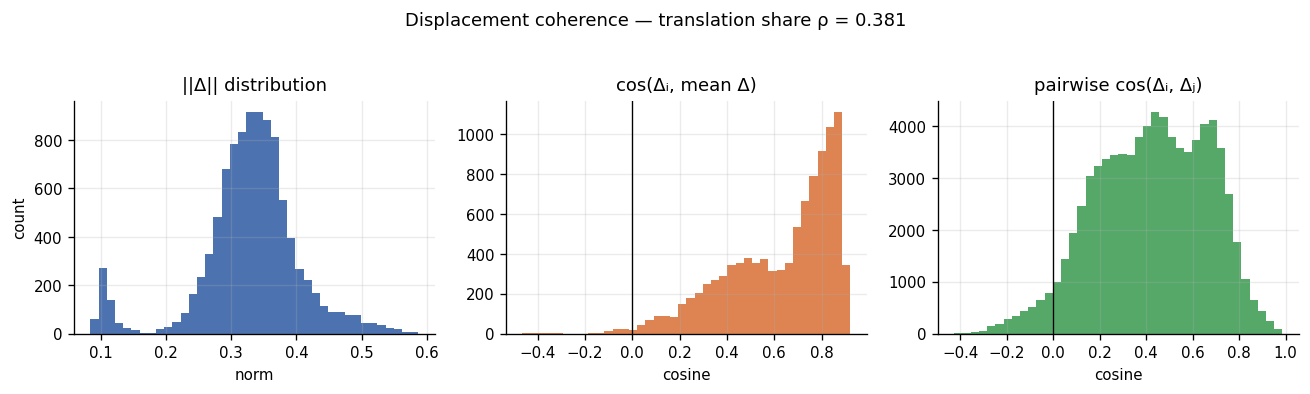

In [5]:
def l2n(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / np.maximum(np.linalg.norm(x, axis=-1, keepdims=True), eps)


def build_deltas(e_aff, e_neg, mode=None, unit=None) -> np.ndarray:
    mode = mode or CONFIG["delta_mode"]
    unit = CONFIG["unit_delta"] if unit is None else unit
    a, b = (l2n(e_aff), l2n(e_neg)) if mode == "normalized" else (e_aff, e_neg)
    d = b - a
    return l2n(d) if unit else d


DELTA = build_deltas(E_AFF, E_NEG)

mean_delta = DELTA.mean(axis=0)
translation_share = float(np.dot(mean_delta, mean_delta) / np.mean(np.sum(DELTA ** 2, axis=1)))

Dn = l2n(DELTA)
cos_to_mean = Dn @ l2n(mean_delta)
sample = rng.choice(N, size=min(N, 400), replace=False)
pair_cos = (Dn[sample] @ Dn[sample].T)[np.triu_indices(len(sample), k=1)]

print(f"translation share  rho = {translation_share:.3f}")
print(f"mean cos(delta_i, mean delta) = {cos_to_mean.mean():.3f}")
print(f"mean pairwise cos(delta_i, delta_j) = {pair_cos.mean():.3f}")
print(f"mean ||delta|| = {np.linalg.norm(DELTA, axis=1).mean():.4f}")

fig, ax = plt.subplots(1, 3, figsize=(11, 3.1))
ax[0].hist(np.linalg.norm(DELTA, axis=1), bins=40, color="#4C72B0")
ax[0].set(title="||Δ|| distribution", xlabel="norm", ylabel="count")
ax[1].hist(cos_to_mean, bins=40, color="#DD8452")
ax[1].axvline(0, color="k", lw=0.8)
ax[1].set(title="cos(Δᵢ, mean Δ)", xlabel="cosine")
ax[2].hist(pair_cos, bins=40, color="#55A868")
ax[2].axvline(0, color="k", lw=0.8)
ax[2].set(title="pairwise cos(Δᵢ, Δⱼ)", xlabel="cosine")
fig.suptitle(f"Displacement coherence — translation share ρ = {translation_share:.3f}", y=1.04)
fig.tight_layout()
plt.show()

In [6]:
print(E_NEG.shape)
print(E_AFF.shape)

E_NEG_norm = E_NEG / np.linalg.norm(E_NEG, axis=1, keepdims=True)
E_AFF_norm = E_AFF / np.linalg.norm(E_AFF, axis=1, keepdims=True)

cosine_similarities = np.sum(E_NEG_norm * E_AFF_norm, axis=1)
print(cosine_similarities)  

#diffs_norms = E_NEG_norm - E_AFF_norm
#diffs_norms_norm = np.linalg.norm(diffs_norms, axis=-1)
#print(diffs_norms_norm)



(10000, 384)
(10000, 384)
[0.9323733  0.92421657 0.93086904 ... 0.9502085  0.9567004  0.96421885]


## 4. Spectrum: second moment (uncentered) and covariance (centered)

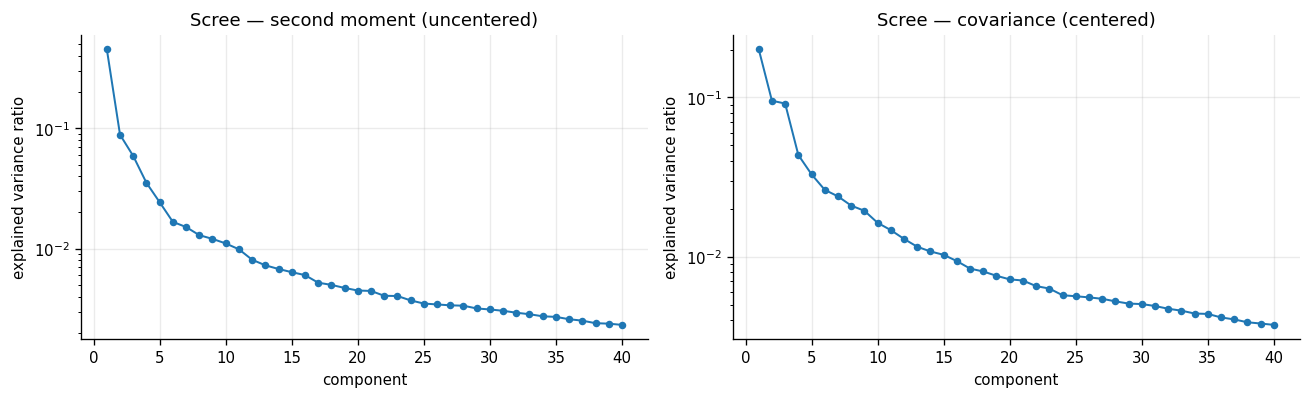

top-1 share  uncentered = 0.456 | centered = 0.201
top-5 share  uncentered = 0.663 | centered = 0.464


In [7]:
@dataclass
class Spectrum:
    eigenvalues: np.ndarray                 # descending
    name: str = ""
    components: np.ndarray | None = None    # (k, d) right singular vectors

    @property
    def p(self) -> np.ndarray:
        """Normalised spectrum — a probability distribution over directions."""
        ev = np.clip(self.eigenvalues, 0, None)
        s = ev.sum()
        return ev / s if s > 0 else ev

    @property
    def cumulative(self) -> np.ndarray:
        return np.cumsum(self.p)


def spectrum_of(X: np.ndarray, center: bool, name: str = "", keep: int | None = None) -> Spectrum:
    """Eigen-spectrum of the (co)variance of the rows of X, computed through the SVD."""
    M = X - X.mean(axis=0, keepdims=True) if center else X
    denom = max(len(M) - 1, 1) if center else len(M)
    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    ev = (s ** 2) / denom
    if keep is not None:
        ev, Vt = ev[:keep], Vt[:keep]
    return Spectrum(eigenvalues=ev, name=name, components=Vt)


SPEC_UNCENTERED = spectrum_of(DELTA, center=False, name="second moment (uncentered)")
SPEC_CENTERED = spectrum_of(DELTA, center=True, name="covariance (centered)")

kmax = min(CONFIG["max_rank_plot"], len(SPEC_UNCENTERED.eigenvalues))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, spec in zip(ax, [SPEC_UNCENTERED, SPEC_CENTERED]):
    a.plot(np.arange(1, kmax + 1), spec.p[:kmax], "o-", ms=3.5, lw=1.2)
    a.set_yscale("log")
    a.set(title=f"Scree — {spec.name}", xlabel="component", ylabel="explained variance ratio")
fig.tight_layout()
plt.show()

print(f"top-1 share  uncentered = {SPEC_UNCENTERED.p[0]:.3f} | centered = {SPEC_CENTERED.p[0]:.3f}")
print(f"top-5 share  uncentered = {SPEC_UNCENTERED.cumulative[4]:.3f} | centered = {SPEC_CENTERED.cumulative[4]:.3f}")

## 5. Information-theoretic dimension estimators

Normalise the spectrum into a distribution $p_i = \lambda_i / \sum_j \lambda_j$. Then:

* **Shannon effective rank** (Roy & Vetterli, 2007): $\;\mathrm{erank} = \exp\big(-\sum_i p_i \log p_i\big)$.
  The canonical information-based dimension: the exponential of the entropy of the spectrum.
* **Participation ratio**: $\;\mathrm{PR} = \big(\sum_i \lambda_i\big)^2 / \sum_i \lambda_i^2 = 1/\sum_i p_i^2$.
  This is $\exp(H_2)$, the Rényi-2 effective rank — less sensitive to the long tail of small eigenvalues.
* **Rényi family**: $\;\mathrm{erank}_\alpha = \big(\sum_i p_i^\alpha\big)^{1/(1-\alpha)}$, with $\alpha \to 1$
  giving Shannon and $\alpha = 2$ giving PR. Sweeping $\alpha$ shows how much the estimate depends on the
  weight given to small eigenvalues — a **flat** curve means the dimension estimate is robust, a steeply
  decreasing one means "the answer depends on where you cut the tail", which is itself diagnostic.
* **Variance thresholds**: $r(\tau) = \min\{k : \sum_{i \le k} p_i \ge \tau\}$.
* **Elbow**: maximum-curvature point of the cumulative curve.

,second moment (uncentered),covariance (centered)
estimator,,
Shannon effective rank exp(H),19.04,52.00
Participation ratio exp(H2),4.49,15.35
Renyi rank alpha=0.5,100.17,147.31
Renyi rank alpha=3,3.23,10.03
Elbow (max curvature),2.00,3.00
Variance threshold tau=0.80,22.00,49.00
Variance threshold tau=0.90,64.00,99.00
Variance threshold tau=0.95,116.00,155.00
Variance threshold tau=0.99,246.00,278.00


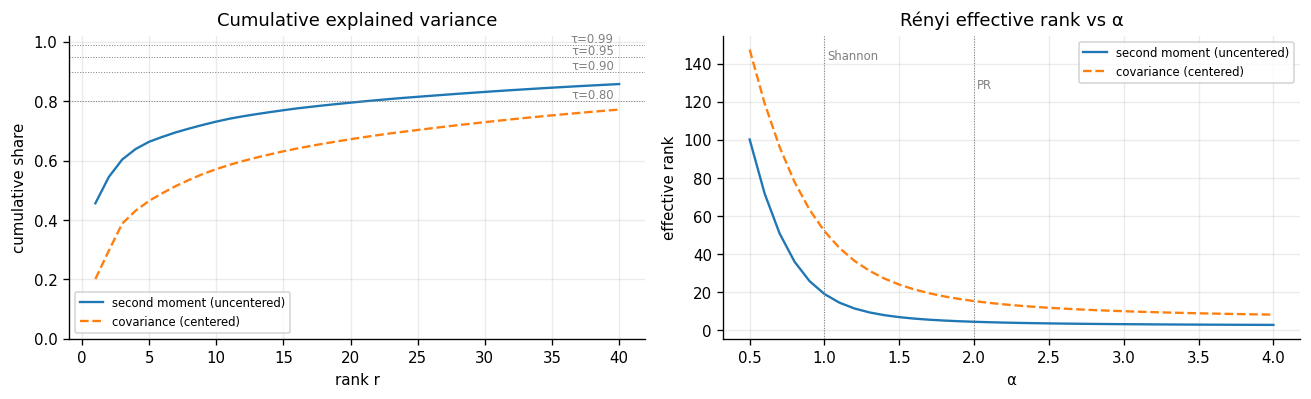

In [8]:
def shannon_effective_rank(p: np.ndarray) -> float:
    q = p[p > 1e-15]
    return float(np.exp(-(q * np.log(q)).sum()))


def participation_ratio(ev: np.ndarray) -> float:
    ev = np.clip(ev, 0, None)
    denom = (ev ** 2).sum()
    return float((ev.sum() ** 2) / denom) if denom > 0 else 0.0


def renyi_effective_rank(p: np.ndarray, alpha: float) -> float:
    q = p[p > 1e-15]
    if abs(alpha - 1.0) < 1e-9:
        return shannon_effective_rank(q)
    return float((q ** alpha).sum() ** (1.0 / (1.0 - alpha)))


def rank_at_threshold(spec: Spectrum, tau: float) -> int:
    return int(np.searchsorted(spec.cumulative, tau) + 1)


def elbow_rank(spec: Spectrum, kmax: int | None = None) -> int:
    """Maximum-curvature index of the cumulative explained-variance curve."""
    c = spec.cumulative[:kmax] if kmax else spec.cumulative
    if len(c) < 4:
        return len(c)
    return int(np.argmax(-np.diff(c, n=2)) + 2)


def estimator_table(spec: Spectrum) -> pd.DataFrame:
    rows = [
        ("Shannon effective rank  exp(H)", shannon_effective_rank(spec.p)),
        ("Participation ratio     exp(H2)", participation_ratio(spec.eigenvalues)),
        ("Renyi rank  alpha=0.5", renyi_effective_rank(spec.p, 0.5)),
        ("Renyi rank  alpha=3", renyi_effective_rank(spec.p, 3.0)),
        ("Elbow (max curvature)", elbow_rank(spec)),
    ]
    rows += [(f"Variance threshold  tau={t:.2f}", rank_at_threshold(spec, t))
             for t in CONFIG["variance_thresholds"]]
    return pd.DataFrame(rows, columns=["estimator", spec.name]).set_index("estimator")


EST = estimator_table(SPEC_UNCENTERED).join(estimator_table(SPEC_CENTERED))
display(EST.round(2))

alphas = np.linspace(0.5, 4.0, 36)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for spec, style in [(SPEC_UNCENTERED, "-"), (SPEC_CENTERED, "--")]:
    ax[0].plot(np.arange(1, kmax + 1), spec.cumulative[:kmax], style, lw=1.4, label=spec.name)
    ax[1].plot(alphas, [renyi_effective_rank(spec.p, a) for a in alphas], style, lw=1.4, label=spec.name)
for t in CONFIG["variance_thresholds"]:
    ax[0].axhline(t, color="grey", lw=0.6, ls=":")
    ax[0].text(kmax * 0.99, t + 0.008, f"τ={t:.2f}", ha="right", fontsize=7, color="grey")
ax[0].set(title="Cumulative explained variance", xlabel="rank r", ylabel="cumulative share", ylim=(0, 1.02))
ax[0].legend(fontsize=7)
ax[1].axvline(1.0, color="grey", lw=0.6, ls=":")
ax[1].axvline(2.0, color="grey", lw=0.6, ls=":")
ax[1].text(1.02, ax[1].get_ylim()[1] * 0.92, "Shannon", fontsize=7, color="grey")
ax[1].text(2.02, ax[1].get_ylim()[1] * 0.82, "PR", fontsize=7, color="grey")
ax[1].set(title="Rényi effective rank vs α", xlabel="α", ylabel="effective rank")
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

## 6. Null models — which components are real?

Even perfectly structureless vectors produce a decaying spectrum when $N \lesssim d$
(Marchenko–Pastur regime). A raw scree plot therefore proves nothing on its own.
Three nulls, from most to least conservative:

| Null | Construction | What it controls for |
|---|---|---|
| `shuffled` | $\Delta = e(\text{neg}_j) - e(\text{aff}_i),\; i \ne j$ | pairing — keeps both marginal distributions |
| `affirmative` | $\Delta = e(\text{aff}_i) - e(\text{aff}_j)$ | **generic semantic difference** between two unrelated sentences |
| `gaussian` | isotropic Gaussian, matched $N, d$, matched total energy | pure sampling noise (the MP baseline) |

`affirmative` is the scientifically interesting one: it answers *"is negation lower-dimensional than an
arbitrary semantic difference?"* rather than merely *"is it lower-dimensional than noise?"*.
Spectra are compared **after normalisation** (shape, not magnitude), and the **significant rank** is the
number of leading components exceeding the null's per-index quantile.

In [ ]:
def null_deltas(kind: str, n: int) -> np.ndarray:
    a, b = (l2n(E_AFF), l2n(E_NEG)) if CONFIG["delta_mode"] == "normalized" else (E_AFF, E_NEG)
    if kind == "shuffled":
        i = rng.integers(0, N, size=n)
        j = rng.integers(0, N, size=n)
        j = np.where(j == i, (j + 1) % N, j)
        d = b[j] - a[i]
    elif kind == "affirmative":
        i = rng.integers(0, N, size=n)
        j = rng.integers(0, N, size=n)
        j = np.where(j == i, (j + 1) % N, j)
        d = a[i] - a[j]
    elif kind == "matched":
        # Content-MATCHED, negation-free control: two affirmative sentences drawn from the same
        # content group (`object`). This is the fair null — "affirmative" pairs unrelated sentences,
        # whose difference is dominated by topic, which is not what we want to compare negation against.
        i, j = _matched_index_pairs(n)
        d = a[i] - a[j]
    elif kind == "gaussian":
        scale = np.sqrt(np.mean(np.sum(DELTA ** 2, axis=1)) / D)
        d = rng.normal(0.0, scale, size=(n, D))
    else:
        raise ValueError(kind)
    return l2n(d) if CONFIG["unit_delta"] else d


def _matched_index_pairs(n: int):
    """Sample (i, j) pairs of distinct rows sharing the same `object` (content) group."""
    groups = df[COLS["object"]].astype(str).values
    buckets = [np.flatnonzero(groups == g) for g in np.unique(groups)]
    buckets = [b for b in buckets if len(b) >= 2]
    if not buckets:
        raise RuntimeError("no content group has >= 2 pairs — 'matched' null unavailable")
    pick = rng.integers(0, len(buckets), size=n)
    i = np.empty(n, dtype=int)
    j = np.empty(n, dtype=int)
    for k, b in enumerate(pick):
        bucket = buckets[b]
        i[k], j[k] = rng.choice(bucket, size=2, replace=False)
    return i, j


def null_spectra(kind: str, n_rep: int | None = None, center: bool = False) -> np.ndarray:
    n_rep = n_rep or CONFIG["n_null"]
    keep = min(CONFIG["max_rank_plot"], N, D)
    out = np.zeros((n_rep, keep))
    for r in range(n_rep):
        spec = spectrum_of(null_deltas(kind, N), center=center, keep=keep)
        out[r] = spec.p[:keep]
    return out


NULL_KINDS = ["shuffled", "affirmative", "gaussian"]
if HAS_OBJECT:
    try:
        _matched_index_pairs(4)
        NULL_KINDS.insert(2, "matched")
    except RuntimeError as e:
        print(f"matched null unavailable: {e}")

NULLS = {k: null_spectra(k) for k in NULL_KINDS}
real_p = SPEC_UNCENTERED.p[:kmax]

sig_rank = {}
for kind, arr in NULLS.items():
    thr = np.quantile(arr[:, :kmax], CONFIG["null_quantile"], axis=0)
    above = real_p > thr
    sig_rank[kind] = int(np.argmin(above)) if not above.all() else int(kmax)  # first index failing the test

print(f"Significant rank (# leading components above the {CONFIG['null_quantile']:.0%} null quantile):")
for k, v in sig_rank.items():
    print(f"  vs {k:12s} -> {v}")

# Prefer the content-matched null when available: it isolates negation from topic variation.
REFERENCE_NULL = "matched" if "matched" in sig_rank else "affirmative"
SIGNIFICANT_RANK = sig_rank[REFERENCE_NULL]
print(f"\nreference null = {REFERENCE_NULL}  ->  significant rank = {SIGNIFICANT_RANK}")

fig, ax = plt.subplots(figsize=(7.6, 4.0))
x = np.arange(1, kmax + 1)
colors = {"shuffled": "#DD8452", "affirmative": "#55A868", "matched": "#C44E52", "gaussian": "#8C8C8C"}
for kind, arr in NULLS.items():
    lo, hi = np.quantile(arr[:, :kmax], [0.05, CONFIG["null_quantile"]], axis=0)
    ax.fill_between(x, lo, hi, alpha=0.22, color=colors[kind], label=f"null: {kind} (5–{CONFIG['null_quantile']:.0%})")
ax.plot(x, real_p, "o-", color="#4C72B0", ms=3.5, lw=1.4, label="observed Δ (negation)")
ax.axvline(SIGNIFICANT_RANK + 0.5, color="k", ls="--", lw=0.9)
ax.text(SIGNIFICANT_RANK + 0.7, real_p.max(), f"significant rank = {SIGNIFICANT_RANK}", fontsize=8)
ax.set_yscale("log")
ax.set(title="Observed spectrum vs null models (normalised)", xlabel="component", ylabel="explained variance ratio")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

## 7. Cross-validated (predictive) rank

Sections 4–6 are **descriptive**: a PCA always describes its own training sample well.
The stricter question is *how many components generalise to pairs never seen*.

Fit $V_r$ (top-$r$ right singular vectors) on a training split, then on held-out Δ measure
$R^2(r) = 1 - \lVert \Delta - V_rV_r^\top\Delta\rVert^2 / \lVert\Delta\rVert^2$.
A random $r$-dimensional subspace already achieves $R^2 \approx r/d$, so the quantity that matters is the
**excess over random**. The plateau of the test curve is the predictive rank.

,rank,R2_train,R2_test,R2_random,excess_over_random
0,1,0.099,0.098,0.002,0.096
1,2,0.160,0.159,0.004,0.155
2,3,0.203,0.202,0.006,0.196
3,4,0.239,0.237,0.009,0.229
4,5,0.271,0.269,0.010,0.259
5,6,0.294,0.292,0.012,0.280
6,7,0.313,0.310,0.014,0.296
7,9,0.346,0.343,0.018,0.325
8,11,0.376,0.373,0.022,0.351
9,14,0.413,0.409,0.027,0.382


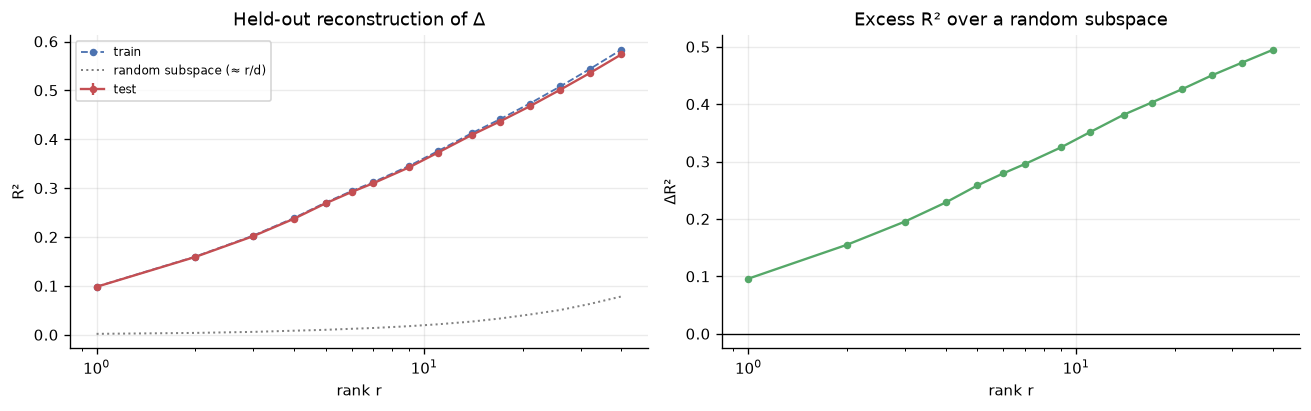

rank maximising excess R² = 40 (excess = 0.495)


In [ ]:
def cv_reconstruction(X: np.ndarray, ranks, n_folds=None, seed=0):
    n_folds = n_folds or CONFIG["cv_folds"]
    ranks = np.asarray(ranks)
    idx = np.random.default_rng(seed).permutation(len(X))
    folds = np.array_split(idx, n_folds)
    r2_test = np.zeros((n_folds, len(ranks)))
    r2_train = np.zeros((n_folds, len(ranks)))
    r2_rand = np.zeros((n_folds, len(ranks)))

    for f, fold in enumerate(folds):
        test = X[fold]
        train = X[np.setdiff1d(idx, fold)]
        _, _, Vt = np.linalg.svd(train, full_matrices=False)
        Q, _ = np.linalg.qr(np.random.default_rng(seed + f).normal(size=(X.shape[1], ranks.max())))
        for c, r in enumerate(ranks):
            Vr = Vt[:r].T
            r2_test[f, c] = 1 - ((test - test @ Vr @ Vr.T) ** 2).sum() / (test ** 2).sum()
            r2_train[f, c] = 1 - ((train - train @ Vr @ Vr.T) ** 2).sum() / (train ** 2).sum()
            Qr = Q[:, :r]
            r2_rand[f, c] = 1 - ((test - test @ Qr @ Qr.T) ** 2).sum() / (test ** 2).sum()

    return ranks, r2_train.mean(0), r2_test.mean(0), r2_test.std(0), r2_rand.mean(0)


RANKS = np.unique(np.clip(np.round(np.geomspace(1, min(CONFIG["max_rank_plot"], N - 2, D), 18)).astype(int), 1, None))
ranks, r2_tr, r2_te, r2_sd, r2_rd = cv_reconstruction(DELTA, RANKS, seed=CONFIG["seed"])
excess = r2_te - r2_rd
predictive_rank = int(ranks[np.argmax(excess)]) if len(ranks) else 1

cv_table = pd.DataFrame({"rank": ranks, "R2_train": r2_tr, "R2_test": r2_te,
                         "R2_random": r2_rd, "excess_over_random": excess})
display(cv_table.round(3))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(ranks, r2_tr, "o--", ms=3.5, lw=1.1, color="#4C72B0", label="train")
ax[0].errorbar(ranks, r2_te, yerr=r2_sd, fmt="o-", ms=3.5, lw=1.4, color="#C44E52", label="test")
ax[0].plot(ranks, r2_rd, ":", lw=1.2, color="grey", label="random subspace (≈ r/d)")
ax[0].set(title="Held-out reconstruction of Δ", xlabel="rank r", ylabel="R²", xscale="log")
ax[0].legend(fontsize=7)
ax[1].plot(ranks, excess, "o-", ms=3.5, lw=1.4, color="#55A868")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(title="Excess R² over a random subspace", xlabel="rank r", ylabel="ΔR²", xscale="log")
fig.tight_layout()
plt.show()

print(f"rank maximising excess R² = {predictive_rank} (excess = {excess.max():.3f})")

## 8. Type structure — H2 vs H3

Three diagnostics, computed on **true negation categories only** (distractors handled in §9):

* **Intra-category coherence** — mean cosine of each Δ to its own category centroid.
  High ⇒ the category has a stable direction.
* **Inter-category cosine** — cosine between category centroids.
  High everywhere ⇒ all types collapse onto one axis (H1 in disguise);
  low ⇒ genuinely distinct sub-axes (H2).
* **Principal angles** between per-category subspaces — the subspace-level generalisation of the cosine.

,n,intra_coherence,participation_ratio
Conditional negation,555,0.728,3.445
Correlative negation,556,0.656,5.015
Partial negation,556,0.599,7.188
Restrictive/exclusive particles,555,0.586,7.258
Aspectual/presuppositional negation,555,0.535,8.590
Neg-raising,555,0.528,7.348
Metalinguistic negation,555,0.512,11.083
Approximate negators,555,0.508,7.469
Exceptors,556,0.478,13.414
Do-support auxiliary,556,0.465,11.325


mean intra-category coherence = 0.485
mean inter-category centroid cosine = 0.262  (min -0.254 / max 0.820)

Reading: high intra + LOW inter  -> H2 (distinct sub-axes per type)
         high intra + HIGH inter -> H1 in disguise (all types share one axis)
         low intra               -> H3 (content dominates over type)


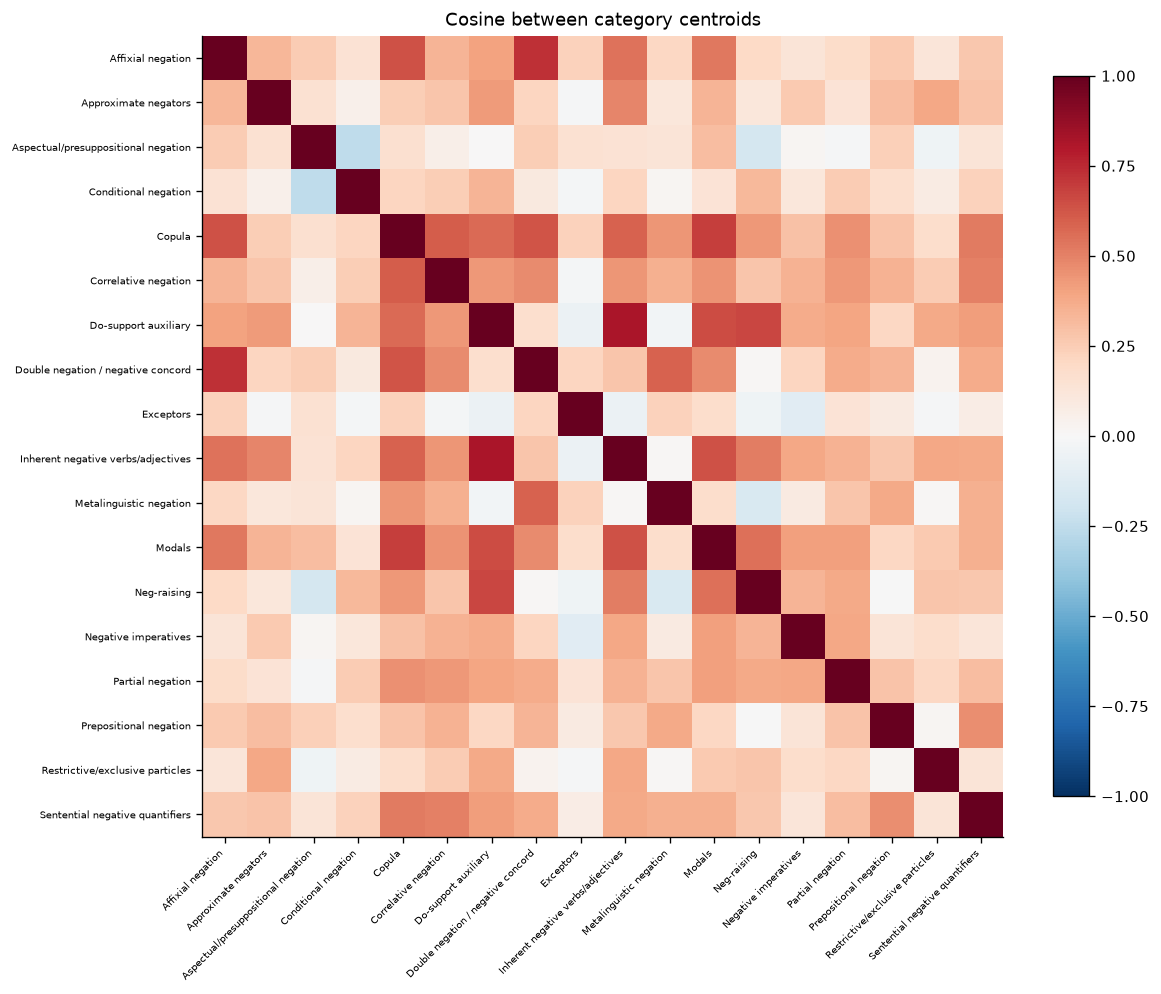

In [ ]:
IS_DIST = df[COLS["is_distractor"]].astype(bool).values
CATS = df[COLS["category"]].values
true_cats = sorted(set(CATS[~IS_DIST]))

centroids, coherence, per_cat_rank, counts = {}, {}, {}, {}
for c in true_cats:
    m = (CATS == c) & (~IS_DIST)
    counts[c] = int(m.sum())
    Dc = DELTA[m]
    cen = Dc.mean(axis=0)
    centroids[c] = cen
    coherence[c] = float(np.mean(l2n(Dc) @ l2n(cen))) if np.linalg.norm(cen) > 0 else 0.0
    per_cat_rank[c] = participation_ratio(spectrum_of(Dc, center=False).eigenvalues) if counts[c] > 2 else np.nan

C = np.stack([l2n(centroids[c]) for c in true_cats])
COS = C @ C.T
off = COS[np.triu_indices(len(true_cats), k=1)]

summary = pd.DataFrame({
    "n": pd.Series(counts),
    "intra_coherence": pd.Series(coherence),
    "participation_ratio": pd.Series(per_cat_rank),
}).sort_values("intra_coherence", ascending=False)
display(summary.round(3))

MEAN_INTRA = float(np.mean(list(coherence.values())))
MEAN_INTER = float(off.mean()) if len(off) else np.nan
print(f"mean intra-category coherence = {MEAN_INTRA:.3f}")
print(f"mean inter-category centroid cosine = {MEAN_INTER:.3f}  (min {off.min():.3f} / max {off.max():.3f})")
print("\nReading: high intra + LOW inter  -> H2 (distinct sub-axes per type)")
print("         high intra + HIGH inter -> H1 in disguise (all types share one axis)")
print("         low intra               -> H3 (content dominates over type)")

# The taxonomy dataset has 18 categories, the demo 7: size the figure with the matrix and drop the
# per-cell annotations once they stop being readable.
n_cat = len(true_cats)
side = max(5.6, 0.40 * n_cat + 3.0)
tick_fs = 7 if n_cat <= 12 else 6
fig, ax = plt.subplots(figsize=(side, side * 0.86))
im = ax.imshow(COS, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(n_cat), true_cats, rotation=45, ha="right", fontsize=tick_fs)
ax.set_yticks(range(n_cat), true_cats, fontsize=tick_fs)
if n_cat <= 12:
    for i in range(n_cat):
        for j in range(n_cat):
            ax.text(j, i, f"{COS[i, j]:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if abs(COS[i, j]) > 0.55 else "black")
ax.set_title("Cosine between category centroids")
ax.grid(False)
fig.colorbar(im, shrink=0.8)
fig.tight_layout()
plt.show()

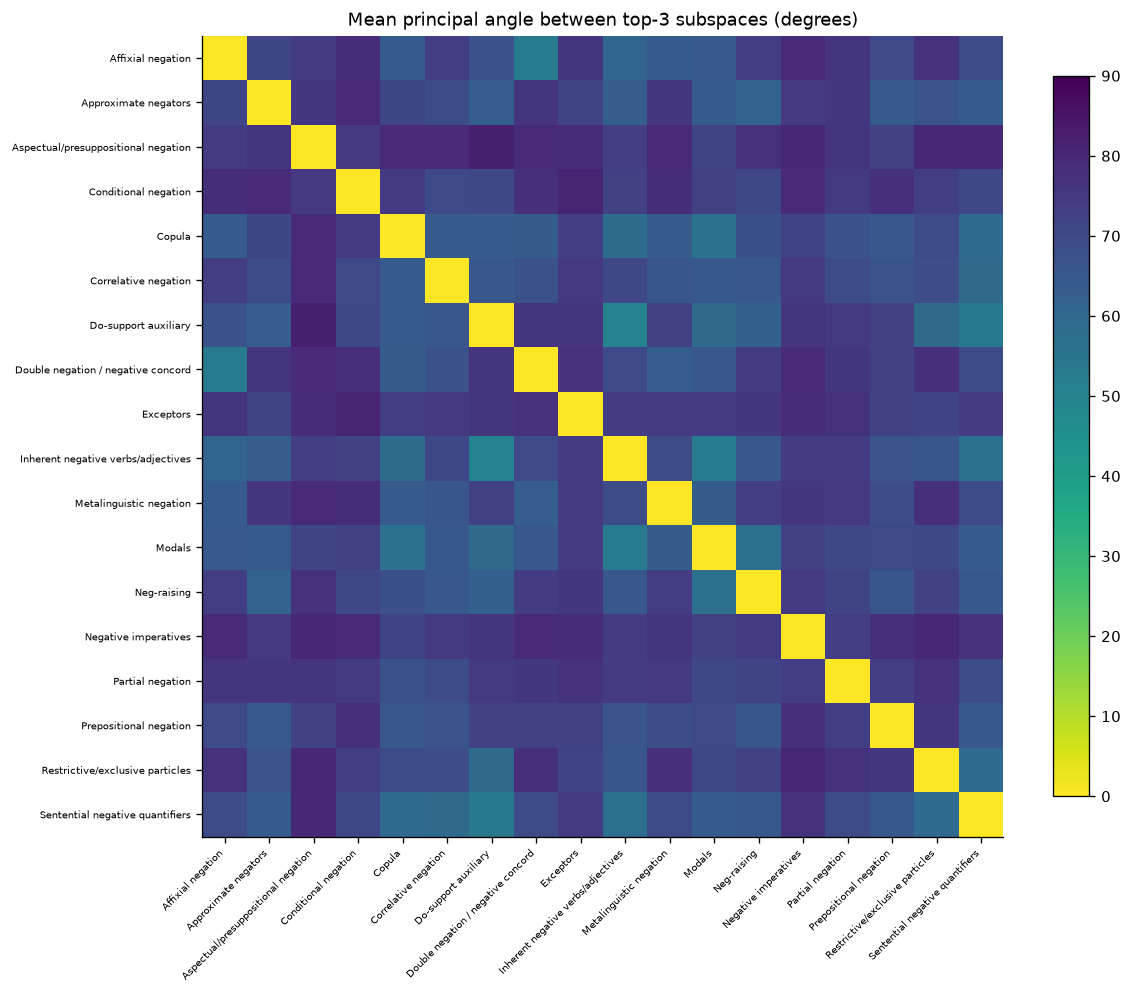

0° = identical subspaces, 90° = orthogonal. Small off-diagonal angles ⇒ shared structure (H1-like).


In [ ]:
def principal_angles(A: np.ndarray, B: np.ndarray, r: int) -> np.ndarray:
    """Principal angles (degrees) between the top-r subspaces spanned by rows of A and B."""
    def basis(X):
        _, _, Vt = np.linalg.svd(X - 0.0, full_matrices=False)
        Q, _ = np.linalg.qr(Vt[:r].T)
        return Q
    s = np.linalg.svd(basis(A).T @ basis(B), compute_uv=False)
    return np.degrees(np.arccos(np.clip(s, -1.0, 1.0)))


R_SUB = 3
eligible = [c for c in true_cats if counts[c] > R_SUB + 1]
if len(eligible) >= 2:
    PA = np.full((len(eligible), len(eligible)), np.nan)
    for i, a in enumerate(eligible):
        for j, b in enumerate(eligible):
            ang = principal_angles(DELTA[(CATS == a) & ~IS_DIST], DELTA[(CATS == b) & ~IS_DIST], R_SUB)
            PA[i, j] = ang.mean()
    n_el = len(eligible)
    side = max(5.6, 0.40 * n_el + 3.0)
    tick_fs = 7 if n_el <= 12 else 6
    fig, ax = plt.subplots(figsize=(side, side * 0.86))
    im = ax.imshow(PA, cmap="viridis_r", vmin=0, vmax=90)
    ax.set_xticks(range(n_el), eligible, rotation=45, ha="right", fontsize=tick_fs)
    ax.set_yticks(range(n_el), eligible, fontsize=tick_fs)
    if n_el <= 12:
        for i in range(n_el):
            for j in range(n_el):
                ax.text(j, i, f"{PA[i, j]:.0f}", ha="center", va="center", fontsize=6.5, color="white")
    ax.set_title(f"Mean principal angle between top-{R_SUB} subspaces (degrees)")
    ax.grid(False)
    fig.colorbar(im, shrink=0.8)
    fig.tight_layout()
    plt.show()
    print("0° = identical subspaces, 90° = orthogonal. Small off-diagonal angles ⇒ shared structure (H1-like).")
else:
    print(f"Not enough pairs per category for subspace angles (need > {R_SUB + 1} each).")

### 8b. How much of the displacement is type structure at all?

Two shares, and only the second one needs a content column.

**Between categories vs within.** The Δ cloud spans over a hundred effective dimensions (§5) while the
category centroids span a handful (§8d). Those cannot both be the same thing, and this split says which is
which: how much of the displacement energy the category means explain, and how much is variation *inside*
the types. A small between-share alongside the reliable per-category directions of §8d is not a
contradiction — the types do point their own way, but each type is itself widely spread, and an operator
built on type centroids only ever addresses the between part.

**Category vs object.** A rank > 1 can mean genuine negation-type structure (H2) or **residual content
leaking into Δ** — the identity of the negated object failing to cancel in the subtraction. Separating
those needs a factorial `category × object` design, so this half runs only when the dataset carries a
content field. *(Exact for balanced designs; approximate otherwise — the code reports the balance.)*

**If the object effect dominates, re-run the whole analysis on object-centred Δ**
($\Delta'_i = \Delta_i - \overline{\Delta}_{\text{object}(i)}$) before concluding anything about types.

In [ ]:
mask = ~IS_DIST
X, cat_v = DELTA[mask], CATS[mask]
grand = X.mean(axis=0)


def between_ss(labels: np.ndarray) -> float:
    """Displacement energy explained by the group means of `labels`."""
    ss = 0.0
    for lv in np.unique(labels):
        m = labels == lv
        ss += m.sum() * float(np.sum((X[m].mean(axis=0) - grand) ** 2))
    return ss


ss_total = float(np.sum((X - grand) ** 2))
ss_cat = between_ss(cat_v)

# The category split needs no `object` column, and it is the one that puts the rank of §5 in
# proportion: the whole Δ cloud spans ~100+ effective dimensions, the category centroids only a
# handful (§8d), so most of that dimensionality has to be variation *inside* the types.
print(f"between categories (type structure) = {ss_cat / ss_total:.3f}")
print(f"within categories  (everything else) = {1 - ss_cat / ss_total:.3f}")
print("\nA small between share with reliable per-category directions (§8d) is not a contradiction:")
print("the types point in their own directions, but each type is itself widely spread. An operator")
print("built on type centroids addresses the between part only.")

if HAS_OBJECT:
    OBJ = df[COLS["object"]].astype(str).values
    obj_v = OBJ[mask]
    ss_obj = between_ss(obj_v)
    ss_res = max(ss_total - ss_cat - ss_obj, 0.0)

    tab = pd.crosstab(cat_v, obj_v)
    balance = float(tab.values.min() / max(tab.values.max(), 1))
    dec = pd.DataFrame({
        "effect": ["category", "object", "residual"],
        "share_of_variance": [ss_cat / ss_total, ss_obj / ss_total, ss_res / ss_total],
    })
    display(dec.round(3))
    print(f"design balance (min/max cell count) = {balance:.2f}  "
          f"({'balanced' if balance > 0.8 else 'UNBALANCED — decomposition is approximate'})")

    fig, ax = plt.subplots(figsize=(5.4, 3.0))
    ax.barh(dec["effect"], dec["share_of_variance"], color=["#4C72B0", "#DD8452", "#BBBBBB"])
    ax.set(title="Displacement variance decomposition", xlabel="share of total variance", xlim=(0, 1))
    fig.tight_layout()
    plt.show()

    if ss_obj > ss_cat:
        print("\nWARNING  Object identity explains more than negation category.")
        print("         Object-centred Δ is computed below — prefer it for the type analysis.")
    DELTA_OBJ_CENTERED = DELTA.copy()
    for lv in np.unique(OBJ):
        m = OBJ == lv
        DELTA_OBJ_CENTERED[m] -= DELTA[m].mean(axis=0)
    spec_oc = spectrum_of(DELTA_OBJ_CENTERED[~IS_DIST], center=False, name="object-centred Δ")
    print(f"\nEffective rank after object-centring: "
          f"Shannon {shannon_effective_rank(spec_oc.p):.2f} | PR {participation_ratio(spec_oc.eigenvalues):.2f}")
else:
    fig, ax = plt.subplots(figsize=(5.4, 2.4))
    ax.barh(["between categories", "within categories"], [ss_cat / ss_total, 1 - ss_cat / ss_total],
            color=["#4C72B0", "#BBBBBB"])
    ax.set(title="Displacement variance: type structure vs the rest", xlabel="share of total variance",
           xlim=(0, 1))
    fig.tight_layout()
    plt.show()

    print("\nNo `object` column — the within-category share above cannot be split further.")
    print("It mixes genuine per-pair variation with content leaking into Δ, and separating those two")
    print("is what a content field crossed with `category` would buy (H2 vs H3).")

No `object` column — skipping the category × object decomposition.
This test is what separates real type structure (H2) from content leakage (H3);
add a controlled `object` field to the generated dataset to enable it.


### 8c. Category by category

§8 asks whether the categories differ; this asks **how each one behaves on its own**. The distinction
matters because a pooled rank of ~18 over 18 categories is the *expected* signature of H2 — and is
indistinguishable from H3 or H4 until the categories are measured separately.

Four panels: ρ per category against the pooled ρ, effective rank per category, whether a coherent type is
also a translation, and — the control — whether a category's coherence simply tracks how many tokens its
negation adds. That last one is the length artefact of §2 made visible: under `mean` pooling a category
whose negation appends a whole clause gets more of its own content back inside Δ, which would show up as
"type structure" that is really pooling.

The second figure overlays the per-category spectra on the pooled one. A pooled curve sitting *above* the
individual ones means the categories occupy different directions, so their union is higher-dimensional
than any single type — which is what H2 predicts and what a pooled spectrum alone cannot show.

In [ ]:
CAT_COL, SUP_COL = COLS["category"], COLS["superclass"]


def _edit_position(a: str, b: str) -> float:
    """Where the first differing word sits, as a fraction of the negated sentence's length.

    0 = the negation edits the first word, 1 = it edits the last. Categories are not equally
    homogeneous — some apply one fixed edit at one fixed place, others pool dozens of different
    markers — and both of those turn out to predict rho in every model tested, so they belong in
    the table beside it rather than in a footnote.
    """
    ta, tb = str(a).lower().split(), str(b).lower().split()
    i = 0
    while i < min(len(ta), len(tb)) and ta[i] == tb[i]:
        i += 1
    return i / max(len(tb), 1)


EDIT_POS = np.array([_edit_position(a, b)
                     for a, b in zip(df[COLS["affirmative"]], df[COLS["negative"]])])

_rows = []
for c in true_cats:
    m = (CATS == c) & (~IS_DIST)
    Dc = DELTA[m]
    mu = Dc.mean(axis=0)
    sp = spectrum_of(Dc, center=False)
    _rows.append({
        "category": c,
        "superclass": df.loc[m, SUP_COL].iloc[0] if HAS_SUPERCLASS else "na",
        "n": int(m.sum()),
        "rho": float(mu @ mu / np.mean(np.sum(Dc ** 2, axis=1))),
        "shannon_rank": shannon_effective_rank(sp.p),
        "participation_ratio": participation_ratio(sp.eigenvalues),
        "intra_coherence": float(np.mean(l2n(Dc) @ l2n(mu))),
        "delta_norm": float(np.linalg.norm(Dc, axis=1).mean()),
        "tokens_added": float(LEN_DELTA[m].mean()),
        "edit_pos": float(EDIT_POS[m].mean()),
        "n_markers": int(df.loc[m, COLS["subclass"]].nunique()),
    })

CAT_STATS = pd.DataFrame(_rows).sort_values("rho", ascending=False).reset_index(drop=True)
display(CAT_STATS.round(3))

_pooled_mu = DELTA[~IS_DIST].mean(axis=0)
RHO_POOLED = float(_pooled_mu @ _pooled_mu / np.mean(np.sum(DELTA[~IS_DIST] ** 2, axis=1)))
print(f"pooled rho = {RHO_POOLED:.3f} vs per-category mean rho = {CAT_STATS['rho'].mean():.3f}")
print("Per-category rho above the pooled one means each type translates coherently while the types")
print("disagree with each other — the H2 signature. Pooling them hides exactly that.")

sups = sorted(CAT_STATS["superclass"].unique())
palette = dict(zip(sups, plt.cm.tab10(np.linspace(0, 1, max(len(sups), 2)))))
colors = [palette[s] for s in CAT_STATS["superclass"]]
short = [c[:30] for c in CAT_STATS["category"]]
y = np.arange(len(CAT_STATS))

fig, ax = plt.subplots(2, 2, figsize=(13, 9))

ax[0, 0].barh(y, CAT_STATS["rho"], color=colors)
ax[0, 0].axvline(RHO_POOLED, color="k", ls="--", lw=1.0, label=f"pooled ρ = {RHO_POOLED:.3f}")
ax[0, 0].set_yticks(y, short, fontsize=7)
ax[0, 0].invert_yaxis()
ax[0, 0].set(title="Translation share ρ per category", xlabel="ρ")
ax[0, 0].legend(fontsize=7)

ax[0, 1].barh(y, CAT_STATS["shannon_rank"], color=colors)
ax[0, 1].set_yticks(y, [], fontsize=7)
ax[0, 1].invert_yaxis()
ax[0, 1].set(title="Effective rank per category (Shannon)", xlabel="exp(H)")

for _, r in CAT_STATS.iterrows():
    ax[1, 0].scatter(r["rho"], r["intra_coherence"], s=45, color=palette[r["superclass"]],
                     edgecolor="k", linewidth=0.4)
    ax[1, 0].annotate(r["category"][:18], (r["rho"], r["intra_coherence"]), fontsize=6,
                      xytext=(3, 3), textcoords="offset points")
ax[1, 0].set(title="Is a coherent type also a translation?", xlabel="ρ", ylabel="intra-category coherence")

# The confound test: mean pooling injects -k/(T+k)*e_aff into Δ, so a category whose negation adds
# more tokens gets more of its own content back. If coherence tracks tokens added, part of the
# apparent type structure is the pooling, not the negation.
r_pearson = float(np.corrcoef(CAT_STATS["tokens_added"], CAT_STATS["intra_coherence"])[0, 1])
for _, r in CAT_STATS.iterrows():
    ax[1, 1].scatter(r["tokens_added"], r["intra_coherence"], s=45, color=palette[r["superclass"]],
                     edgecolor="k", linewidth=0.4)
    ax[1, 1].annotate(r["category"][:18], (r["tokens_added"], r["intra_coherence"]), fontsize=6,
                      xytext=(3, 3), textcoords="offset points")
ax[1, 1].set(title=f"Confound check — Pearson r = {r_pearson:+.2f}",
             xlabel="tokens added by the negation", ylabel="intra-category coherence")

handles = [plt.Line2D([], [], marker="o", ls="", color=palette[s], label=s) for s in sups]
fig.legend(handles=handles, fontsize=7, loc="lower center", ncol=min(len(sups), 4),
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Negation category by category — {MSPEC['repo']} ({POOLING} pooling), N = {N}", y=1.0)
fig.tight_layout()
plt.show()

print(f"\ncorr(tokens added, intra coherence) = {r_pearson:+.3f}")
for _v in ("tokens_added", "edit_pos", "n_markers"):
    print(f"corr({_v:13s}, rho)        = {float(np.corrcoef(CAT_STATS[_v], CAT_STATS['rho'])[0, 1]):+.3f}")
print("An early edit and a single marker both predict a translation-like category, in every model")
print("tested (clip, bert, both e5). Not a property of causal attention then — wide-scope operators")
print("sit early in the sentence, and a category pooling 26 different affixes is not one direction.")
# Only a POSITIVE correlation matches the artefact: the leaked term -k/(T+k)*e_aff grows with k and
# aligns within a category, so it would inflate coherence exactly where the negation adds most tokens.
if POOLING == "mean" and r_pearson > 0.4:
    print("WARNING  positive correlation under mean pooling: the length artefact of §2 is inflating")
    print("         coherence where the negation adds most tokens. Re-run under a single-position")
    print("         pooling before reading this as type structure.")
elif r_pearson < -0.4:
    print("NOTE  the correlation is NEGATIVE, the opposite of the mean-pooling artefact. Categories")
    print("      that append a long, variable clause (metalinguistic, exceptors) have a less coherent")
    print("      Δ than those inserting one fixed particle — a property of the edit, not of pooling.")

fig, ax = plt.subplots(figsize=(7.6, 4.2))
kshow = min(20, N // len(true_cats))
for _, r in CAT_STATS.iterrows():
    m = (CATS == r["category"]) & (~IS_DIST)
    p = spectrum_of(DELTA[m], center=False).p[:kshow]
    ax.plot(np.arange(1, len(p) + 1), p, lw=1.0, alpha=0.8, color=palette[r["superclass"]])
p_pooled = spectrum_of(DELTA[~IS_DIST], center=False).p[:kshow]
ax.plot(np.arange(1, len(p_pooled) + 1), p_pooled, lw=2.4, color="k", label="pooled (all categories)")
ax.set_yscale("log")
ax.set(title="Per-category spectra (one line per category, coloured by superclass)",
       xlabel="component", ylabel="explained variance ratio")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()

print("A pooled curve ABOVE the per-category ones means the categories occupy different directions:")
print("their union is higher-dimensional than any of them alone. That is what H2 predicts, and it is")
print("invisible in the pooled spectrum alone — which is why §5-§7 cannot decide H2 vs H3 by themselves.")

### 8d. Does each category own a direction?

§8 compares category centroids, which answers "do the types differ". This asks the sharper question that
H2 actually stakes: **is there, per category, a direction that exists, is its own, and is recoverable from
a single pair?** Three measurements, each closing a different escape route.

**Reliability — does the direction exist?** Split each category in half at random and take the cosine
between the two half-centroids, averaged over 20 draws. A real direction is reproducible on disjoint
samples. This is stricter than intra-coherence, which a category with a huge spread can still pass by
averaging, and the bar to clear is drawn on the plot: the mean inter-category cosine. A split-half of 0.9
against an inter-category cosine of 0.25 means the direction is both stable and specific; a split-half no
higher than the inter-category level means the "category direction" is just the shared negation direction
seen through a small sample.

**Dimensionality — how many directions are there really?** The strict reading of H2, one sub-axis per type,
predicts that 18 categories span close to 18 effective dimensions. The spectrum of the 18 unit centroids
says how many they actually occupy: a participation ratio of 3 would mean the types differ only along a
few shared axes, whatever their pairwise cosines suggest.

**Recoverability — and the control that matters.** Fit one centroid per category on training folds, then
name the category of each held-out Δ by cosine. Chance is 1/18 = 0.056. But the same classifier is also run
on the **affirmative embedding alone**: in this dataset every category carries its own sentence templates,
so the affirmative already betrays the category. If Δ classifies no better than the affirmative does, the
"negation direction" is inherited sentence form rather than negation geometry. The confusion matrix is
ordered by superclass with the boundaries drawn, so a geometry that rediscovers the linguistic grouping
shows up as blocks on the diagonal.

In [ ]:
SUPS = {c: (df.loc[(CATS == c) & (~IS_DIST), SUP_COL].iloc[0] if HAS_SUPERCLASS else "na")
        for c in true_cats}


# ---- 1. split-half reliability: does a category have a direction at all? -------------
def split_half_cosine(c: str, n_rep: int = 20) -> float:
    """Cosine between the centroids of two random halves of a category.

    A direction that exists is reproducible: two disjoint halves of the same category must
    agree. Unlike intra-coherence this is not inflated by the spread of individual Δ, and
    with balanced categories it is comparable across them.
    """
    idx = np.flatnonzero((CATS == c) & (~IS_DIST))
    g = np.random.default_rng(CONFIG["seed"])
    out = []
    for _ in range(n_rep):
        p = g.permutation(idx)
        a, b = p[: len(p) // 2], p[len(p) // 2:]
        out.append(float(l2n(DELTA[a].mean(axis=0)) @ l2n(DELTA[b].mean(axis=0))))
    return float(np.mean(out))


RELIAB = pd.DataFrame({
    "category": true_cats,
    "superclass": [SUPS[c] for c in true_cats],
    "n": [counts[c] for c in true_cats],
    "split_half": [split_half_cosine(c) for c in true_cats],
    "intra_coherence": [coherence[c] for c in true_cats],
}).sort_values("split_half", ascending=False).reset_index(drop=True)
display(RELIAB.round(3))
print(f"mean split-half reliability = {RELIAB['split_half'].mean():.3f}")
print(f"mean inter-category cosine  = {MEAN_INTER:.3f}   <- the level a direction must beat to be its own")


# ---- 2. how many directions do the 18 categories actually occupy? -------------------
C_UNIT = np.stack([l2n(centroids[c]) for c in true_cats])
SPEC_CEN = spectrum_of(C_UNIT, center=False, name="category centroids")
cen_shannon = shannon_effective_rank(SPEC_CEN.p)
cen_pr = participation_ratio(SPEC_CEN.eigenvalues)
cen_90 = rank_at_threshold(SPEC_CEN, 0.90)
print(f"\n{len(true_cats)} categories span: Shannon rank {cen_shannon:.2f} | PR {cen_pr:.2f} | "
      f"{cen_90} components for 90% of the centroid energy")
print("One sub-axis per type (strict H2) predicts these to approach the number of categories;")
print("a handful means the types differ along only a few shared axes.")


# ---- 3. can a single Δ name its own category? ---------------------------------------
def centroid_cv(X: np.ndarray, labels: np.ndarray, n_folds: int = 5, seed: int = 0):
    """Nearest-centroid classification in cosine, centroids fitted on training folds only."""
    Xn = l2n(X)
    labs = np.unique(labels)
    pos = {l: i for i, l in enumerate(labs)}
    idx = np.random.default_rng(seed).permutation(len(X))
    conf = np.zeros((len(labs), len(labs)), dtype=int)
    for f in np.array_split(idx, n_folds):
        tr = np.setdiff1d(idx, f)
        cen = np.stack([l2n(Xn[tr][labels[tr] == l].mean(axis=0)) for l in labs])
        pred = labs[np.argmax(Xn[f] @ cen.T, axis=1)]
        for t, p in zip(labels[f], pred):
            conf[pos[t], pos[p]] += 1
    return float(np.trace(conf) / conf.sum()), conf, labs


keep = ~IS_DIST
ACC_DELTA, CONF, LABS = centroid_cv(DELTA[keep], CATS[keep], seed=CONFIG["seed"])
# Control: the same classifier on the affirmative sentence alone. Each category uses its own
# templates, so the affirmative already betrays the category — this says how much of the
# "category direction" is negation geometry rather than inherited sentence form.
ACC_AFF, _, _ = centroid_cv(l2n(E_AFF)[keep], CATS[keep], seed=CONFIG["seed"])
CHANCE = 1.0 / len(LABS)

print(f"\ncategory recovered from the direction of one Δ : {ACC_DELTA:.3f}")
print(f"same classifier on the affirmative embedding   : {ACC_AFF:.3f}   (template/content control)")
print(f"chance                                         : {CHANCE:.3f}")

err = CONF.copy()
np.fill_diagonal(err, 0)
sup_of = np.array([SUPS[l] for l in LABS])
same_sup = float(sum(err[i, j] for i in range(len(LABS)) for j in range(len(LABS))
                     if i != j and sup_of[i] == sup_of[j]))
sizes = pd.Series(sup_of).value_counts()
exp_same = float(np.mean([(sizes[s] - 1) / (len(LABS) - 1) for s in sup_of]))
print(f"\nconfusions falling inside the same superclass  : {same_sup / max(err.sum(), 1):.3f} "
       f"(expected by chance {exp_same:.3f})")
print("Above chance means the geometry rediscovers the linguistic grouping on its own.")

order = np.argsort([f"{SUPS[l]}|{l}" for l in LABS])
CONF_N = CONF[np.ix_(order, order)] / np.maximum(CONF.sum(axis=1, keepdims=True)[order], 1)
lab_ord = [LABS[i] for i in order]

fig = plt.figure(figsize=(14, 5.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 0.85, 1.3], wspace=0.35)

ax0 = fig.add_subplot(gs[0])
y = np.arange(len(RELIAB))
ax0.barh(y, RELIAB["split_half"], color=[palette[s] for s in RELIAB["superclass"]])
ax0.axvline(MEAN_INTER, color="k", ls="--", lw=1.0, label=f"inter-category cosine = {MEAN_INTER:.2f}")
ax0.set_yticks(y, [c[:28] for c in RELIAB["category"]], fontsize=7)
ax0.invert_yaxis()
ax0.set(title="Split-half reliability of each direction", xlabel="cos(half A, half B)", xlim=(0, 1))
ax0.legend(fontsize=7, loc="lower right")

ax1 = fig.add_subplot(gs[1])
ax1.plot(np.arange(1, len(SPEC_CEN.p) + 1), SPEC_CEN.p, "o-", ms=4, color="#4C72B0")
ax1.set_yscale("log")
ax1.set(title=f"Spectrum of the {len(true_cats)} centroids", xlabel="component",
        ylabel="share of centroid energy")
ax1.axhline(1 / len(true_cats), color="grey", ls=":", lw=1.0)
ax1.text(len(true_cats) * 0.45, 1 / len(true_cats) * 1.15,
         f"flat = {len(true_cats)} equal axes", fontsize=7, color="grey")
ax1.set_title(f"Centroid spectrum — Shannon {cen_shannon:.1f}, PR {cen_pr:.1f}", fontsize=9)

ax2 = fig.add_subplot(gs[2])
im = ax2.imshow(CONF_N, cmap="magma_r", vmin=0, vmax=1)
bounds = [i for i in range(1, len(lab_ord)) if SUPS[lab_ord[i]] != SUPS[lab_ord[i - 1]]]
for b in bounds:
    ax2.axhline(b - 0.5, color="#4C72B0", lw=1.0)
    ax2.axvline(b - 0.5, color="#4C72B0", lw=1.0)
ax2.set_xticks(range(len(lab_ord)), [c[:22] for c in lab_ord], rotation=90, fontsize=6)
ax2.set_yticks(range(len(lab_ord)), [c[:22] for c in lab_ord], fontsize=6)
ax2.set(title=f"Confusion of Δ direction — accuracy {ACC_DELTA:.2f} (chance {CHANCE:.2f})",
        xlabel="predicted", ylabel="true")
ax2.grid(False)
fig.colorbar(im, ax=ax2, shrink=0.75)
fig.suptitle(f"Does each negation category own a direction? — {MSPEC['repo']} ({POOLING}), N = {N}", y=1.02)
plt.show()

### 8e. One shared axis, or families that can be merged?

§8d found that 18 categories span only a handful of effective dimensions — 6.6 on CLIP, 2.5 on
multilingual E5. That invites the conclusion that categories can be merged, and it is worth resisting
until tested, because two very different geometries produce the same low number.

**One shared axis.** Every category carries the same generic negation direction plus a small idiosyncratic
remainder. The participation ratio collapses, yet nothing is mergeable: the categories are 18 shades of
one direction, all equally far from each other.

**Families.** Some categories are nearly collinear with each other and distinct from the rest. Then
merging is exactly the right move, and the merged set is the honest unit of analysis.

The two are separable arithmetically. If a shared axis accounts for a fraction $s$ of every centroid and
the remainder is isotropic, the participation ratio is predicted by $1/(s^2 + (1-s)^2/(k-1))$. The cell
prints that prediction beside the observed value, then **removes the shared axis and recomputes**. A
residual participation ratio near $k-1$ with residual cosines near zero settles it in favour of one axis;
a residual that stays low, with some pairs still strongly aligned, means families.

Only if families survive that test does the clustering below mean anything — and it is checked twice more:
against the linguistic superclasses with an adjusted Rand index, and against itself on two disjoint halves
of the data. A family that appears in one half and not the other is sampling noise, not a merge candidate.

In [ ]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.metrics import adjusted_rand_score

# ---- 1. one shared axis, or genuine families? ---------------------------------------
COS_CEN = C_UNIT @ C_UNIT.T
off_all = COS_CEN[np.triu_indices(len(true_cats), k=1)]

SHARED = l2n(C_UNIT.mean(axis=0))                  # the direction every category has in common
share_energy = float(np.mean((C_UNIT @ SHARED) ** 2))
C_RES = l2n(C_UNIT - np.outer(C_UNIT @ SHARED, SHARED))
COS_RES = C_RES @ C_RES.T
off_res = COS_RES[np.triu_indices(len(true_cats), k=1)]
spec_res = spectrum_of(C_RES, center=False)
pr_res = participation_ratio(spec_res.eigenvalues)

# A shared axis carrying a fraction s of every centroid, with an isotropic remainder, predicts
# this participation ratio. Comparing it to the observed one says how much of the collapse is
# just that one axis, before any talk of families.
_s = float(np.mean(off_all))
k = len(true_cats)
pr_predicted = 1.0 / (_s ** 2 + (1 - _s) ** 2 / (k - 1))

print(f"mean inter-centroid cosine        = {np.mean(off_all):+.3f}  (max {off_all.max():+.3f})")
print(f"energy along the shared axis      = {share_energy:.3f}")
print(f"centroid PR observed              = {cen_pr:.2f}")
print(f"   predicted by one shared axis   = {pr_predicted:.2f}   <- if this matches, the collapse")
print(f"   after removing the shared axis = {pr_res:.2f}         is that axis, not families")
print(f"mean residual cosine              = {np.mean(off_res):+.3f}  (max {off_res.max():+.3f})")
print("A residual PR near k-1 with residual cosines near zero means 18 shades of one direction.")
print("A residual PR still low, with some residual cosines high, means real families.")

# ---- 2. families, if any ------------------------------------------------------------
DIST = np.clip(1.0 - COS_RES, 0, 2)
np.fill_diagonal(DIST, 0.0)
DIST = (DIST + DIST.T) / 2
Z = linkage(squareform(DIST, checks=False), method="average")

N_CLUSTERS = 6
labels_geo = fcluster(Z, N_CLUSTERS, criterion="maxclust")
labels_sup = pd.factorize([SUPS[c] for c in true_cats])[0]
ARI_SUPERCLASS = ari_sup = float(adjusted_rand_score(labels_sup, labels_geo))

print(f"\ngeometric families at k={N_CLUSTERS} vs the {len(set(labels_sup))} linguistic superclasses:")
print(f"  adjusted Rand index = {ari_sup:+.3f}   (0 = unrelated, 1 = identical partitions)")
for g in range(1, N_CLUSTERS + 1):
    members = [true_cats[i] for i in range(len(true_cats)) if labels_geo[i] == g]
    if members:
        sup_of_members = {SUPS[m] for m in members}
        print(f"  family {g}: {', '.join(m[:26] for m in members)}")
        print(f"            superclasses involved: {', '.join(sorted(sup_of_members))}")

# ---- 3. are those families reproducible? --------------------------------------------
# Cluster the centroids of two disjoint halves of the data and compare the partitions. A family
# that only exists in one half is sampling noise, not a merge candidate.
g = np.random.default_rng(CONFIG["seed"])
halves = []
for h in range(2):
    cen_h = []
    for c in true_cats:
        idx = np.flatnonzero((CATS == c) & (~IS_DIST))
        p = g.permutation(idx) if h == 0 else np.flip(g.permutation(idx))
        cen_h.append(l2n(DELTA[p[: len(p) // 2]].mean(axis=0)))
    Ch = np.stack(cen_h)
    Ch = l2n(Ch - np.outer(Ch @ SHARED, SHARED))
    Dh = np.clip(1.0 - Ch @ Ch.T, 0, 2)
    np.fill_diagonal(Dh, 0.0)
    Dh = (Dh + Dh.T) / 2
    halves.append(fcluster(linkage(squareform(Dh, checks=False), method="average"),
                           N_CLUSTERS, criterion="maxclust"))
ARI_STABILITY = float(adjusted_rand_score(*halves))
print(f"\nsplit-half stability of the families: ARI = {ARI_STABILITY:+.3f}")
print("Below ~0.3 the families are not reproducible and should not be merged.")

# ---- 4. are they families of negation, or of sentence templates? --------------------
# Every category writes its own templates, and the affirmative alone already predicts the
# category (§8d). So run the identical pipeline on the affirmative centroids: if the two
# partitions agree, the families are sentence form rather than negation geometry.
def _families(vectors: np.ndarray, n_clusters: int = N_CLUSTERS) -> np.ndarray:
    V = l2n(vectors)
    shared = l2n(V.mean(axis=0))
    V = l2n(V - np.outer(V @ shared, shared))
    D = np.clip(1.0 - V @ V.T, 0, 2)
    np.fill_diagonal(D, 0.0)
    D = (D + D.T) / 2
    return fcluster(linkage(squareform(D, checks=False), method="average"),
                    n_clusters, criterion="maxclust")


C_AFF_CEN = np.stack([l2n(AFFN_CEN := l2n(E_AFF)[(CATS == c) & (~IS_DIST)].mean(axis=0))
                      for c in true_cats])
labels_aff = _families(C_AFF_CEN)
ARI_TEMPLATES = ari_templates = float(adjusted_rand_score(labels_aff, labels_geo))
print(f"\nsame clustering run on the AFFIRMATIVE centroids: ARI vs the Δ families = {ari_templates:+.3f}")
print("High means the families are groups of sentence templates that Δ inherits; low means the")
print("grouping belongs to the negation displacement itself.")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
dn = dendrogram(Z, labels=[c[:26] for c in true_cats], ax=ax[0], color_threshold=Z[-(N_CLUSTERS - 1), 2],
                leaf_font_size=7, orientation="right")
ax[0].set(title="Categories clustered on their residual direction\n(shared negation axis removed)",
          xlabel="1 − cosine")
ax[0].grid(False)

order = dn["leaves"]
M = COS_RES[np.ix_(order, order)]
im = ax[1].imshow(M, cmap="RdBu_r", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(order)), [true_cats[i][:24] for i in order], rotation=90, fontsize=6)
ax[1].set_yticks(range(len(order)), [true_cats[i][:24] for i in order], fontsize=6)
ax[1].set(title="Residual cosine, reordered by the dendrogram")
ax[1].grid(False)
fig.colorbar(im, ax=ax[1], shrink=0.8)
fig.suptitle(f"Can negation categories be merged? — {MSPEC['repo']} ({POOLING}), N = {N}", y=1.0)
fig.tight_layout()
plt.show()

### 8f. Verdict on type structure

Sections 8b to 8e each answer one question; this one puts the answers together and prints the evidence
behind each claim, so the conclusion can be read off a run rather than taken on trust.

**How many directions do the negation types occupy?** Not the raw centroid rank — that number is
dominated by the single direction every category shares. The honest form is *one shared axis plus however
many directions remain once it is removed*, and both halves are printed with the measurement that produced
them.

**Which types can be merged?** Only if the families pass all three checks: they must reproduce on disjoint
halves of the data, they must not be the same grouping the affirmative sentences produce on their own, and
their relation to the linguistic superclasses is reported rather than assumed. A failure on either of the
first two is fatal, and the cell says so instead of printing families.

In [ ]:
line = "=" * 74
print(line)
print(f"  TYPE STRUCTURE — {MSPEC['repo']} ({POOLING}) — {N} pairs, {len(true_cats)} categories")
print(line)

print("\n  HOW MANY DIRECTIONS DO THE TYPES OCCUPY?\n")
print(f"      1 shared direction, carrying {share_energy:.0%} of the centroid energy")
print(f"    + {pr_res:.1f} further directions that tell the types apart")
print(f"\n    evidence: participation ratio of the {len(true_cats)} centroids = {cen_pr:.2f},")
print(f"              which rises to {pr_res:.2f} once the shared axis is projected out.")
print(f"              (a single shared axis alone would predict {pr_predicted:.2f})")
print(f"    for scale: the whole Δ cloud spans {participation_ratio(SPEC_UNCENTERED.eigenvalues):.1f} "
      f"(PR) / {shannon_effective_rank(SPEC_UNCENTERED.p):.1f} (Shannon) directions,")
print(f"              and the category means account for {ss_cat / ss_total:.0%} of its energy (§8b).")

print("\n  CAN TYPES BE MERGED?\n")
ok_stable = ARI_STABILITY > 0.30
ok_not_templates = ARI_TEMPLATES < 0.30
print(f"    reproduce on disjoint halves    ARI {ARI_STABILITY:+.3f}   "
      f"{'PASS' if ok_stable else 'FAIL'}  (needs > +0.30)")
print(f"    not a grouping of templates     ARI {ARI_TEMPLATES:+.3f}   "
      f"{'PASS' if ok_not_templates else 'FAIL'}  (needs < +0.30)")
print(f"    vs the linguistic superclasses  ARI {ARI_SUPERCLASS:+.3f}   "
      f"{'the geometry is not the taxonomy' if ARI_SUPERCLASS < 0.30 else 'matches the taxonomy'}")

if ok_stable and ok_not_templates:
    print(f"\n    -> yes, in this space. The {N_CLUSTERS} families:\n")
    for g in range(1, N_CLUSTERS + 1):
        members = [true_cats[i] for i in range(len(true_cats)) if labels_geo[i] == g]
        if len(members) > 1:
            print(f"       [{len(members)}] {', '.join(members)}")
    singles = [true_cats[i] for i in range(len(true_cats))
               if sum(labels_geo == labels_geo[i]) == 1]
    if singles:
        print(f"       alone: {', '.join(singles)}")
else:
    print("\n    -> NO. A failed check means the families are an artefact; do not merge on them.")

print(f"\n  Valid for {MSPEC['repo']}. Re-run under another model before generalising: this")
print("  notebook finds reproducible families on the retrieval encoders and none on CLIP,")
print("  on identical data, so mergeability is a property of the space, not of negation.")
print(line)

## 9. Distractor validity check (`mis-`, `anti-`)

`misunderstand` ≠ `not understand` and `antisocial` ≠ `not social`: these prefixes *look* negative but are
not semantic negation. Fit the subspace on true negation categories only, then measure how much of each
category's displacement energy it captures: $\;\lVert P_r\Delta\rVert^2/\lVert\Delta\rVert^2$.

**Distractors scoring like true categories ⇒ the geometry is keying on a surface morphological cue**,
the same failure mode NegBench documents for ConCLIP (all "negative-looking" captions collapsing together).

In [ ]:
if IS_DIST.any():
    R_FIT = max(1, min(SIGNIFICANT_RANK, 8))
    _, _, Vt_true = np.linalg.svd(DELTA[~IS_DIST], full_matrices=False)
    P = Vt_true[:R_FIT].T @ Vt_true[:R_FIT]
    captured = np.sum((DELTA @ P) ** 2, axis=1) / np.maximum(np.sum(DELTA ** 2, axis=1), 1e-12)

    res = (pd.DataFrame({"category": CATS, "is_distractor": IS_DIST, "captured": captured})
           .groupby(["is_distractor", "category"])["captured"].agg(["mean", "std", "size"])
           .sort_values("mean", ascending=False))
    display(res.round(3))

    baseline = R_FIT / D
    print(f"random-subspace baseline = r/d = {baseline:.3f}   (fitted rank r = {R_FIT})")
    print(f"true categories mean  = {captured[~IS_DIST].mean():.3f}")
    print(f"distractors  mean     = {captured[IS_DIST].mean():.3f}")
    verdict_dist = ("PASS — distractors are clearly outside the negation subspace"
                    if captured[IS_DIST].mean() < 0.6 * captured[~IS_DIST].mean()
                    else "FAIL — distractors sit inside the subspace: likely a surface-form shortcut")
    print(f"\n{verdict_dist}")

    fig, ax = plt.subplots(figsize=(7.2, 3.4))
    order = res.reset_index().sort_values("mean", ascending=False)
    ax.bar(range(len(order)), order["mean"],
           color=["#C44E52" if d else "#4C72B0" for d in order["is_distractor"]])
    ax.axhline(baseline, color="k", ls=":", lw=1.0, label="random subspace r/d")
    ax.set_xticks(range(len(order)), order["category"], rotation=45, ha="right", fontsize=7)
    ax.set(title="Energy captured by the negation subspace (red = distractor)", ylabel="captured fraction")
    ax.legend(fontsize=7)
    fig.tight_layout()
    plt.show()
else:
    print("No distractor rows (`is_distractor` all False) — add `mis-` / `anti-` pairs to enable this check.")

No distractor rows (`is_distractor` all False) — add `mis-` / `anti-` pairs to enable this check.


## 10. Low-dimensional visualisations

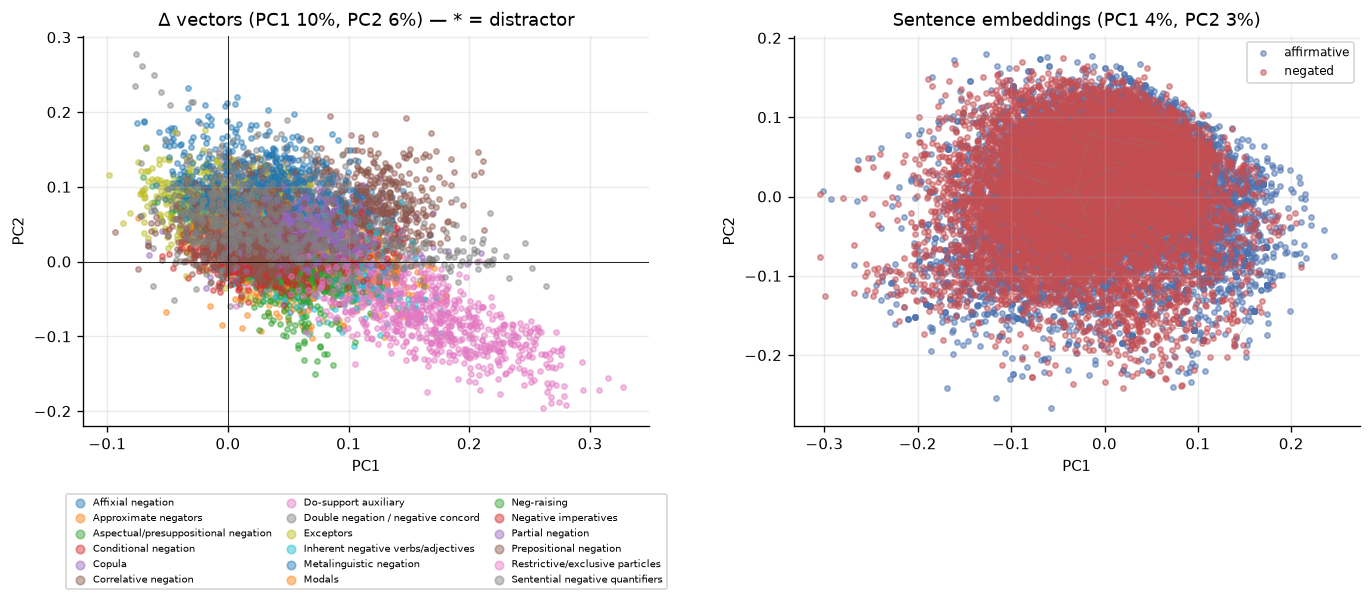

In [ ]:
def pca_2d(X: np.ndarray, center=True):
    M = X - X.mean(axis=0, keepdims=True) if center else X
    U, s, Vt = np.linalg.svd(M, full_matrices=False)
    return M @ Vt[:2].T, (s[:2] ** 2) / (s ** 2).sum()


Z_delta, ev_delta = pca_2d(DELTA, center=False)
all_cats = sorted(set(CATS))
# Marker size and legend layout follow N and the number of categories: 10k points x 18 categories
# needs smaller, more transparent dots and a legend outside the axes.
dot_s, dot_a = (10, 0.45) if N > 2000 else (16, 0.75)
fig, ax = plt.subplots(1, 2, figsize=(11.5, 5.2))

for c in all_cats:
    m = CATS == c
    dist = bool(IS_DIST[m][0])
    ax[0].scatter(Z_delta[m, 0], Z_delta[m, 1], s=dot_s, alpha=dot_a, label=c + (" *" if dist else ""),
                  marker="x" if dist else "o")
ax[0].axhline(0, color="k", lw=0.5)
ax[0].axvline(0, color="k", lw=0.5)
ax[0].set(title=f"Δ vectors (PC1 {ev_delta[0]:.0%}, PC2 {ev_delta[1]:.0%}) — * = distractor",
          xlabel="PC1", ylabel="PC2")
ax[0].legend(fontsize=6, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.16),
             markerscale=1.6, handletextpad=0.3, columnspacing=0.9)

both = np.vstack([l2n(E_AFF), l2n(E_NEG)])
Z_both, ev_both = pca_2d(both)
half = len(E_AFF)
ax[1].scatter(Z_both[:half, 0], Z_both[:half, 1], s=dot_s, alpha=0.5, label="affirmative", color="#4C72B0")
ax[1].scatter(Z_both[half:, 0], Z_both[half:, 1], s=dot_s, alpha=0.5, label="negated", color="#C44E52")
for i in rng.choice(half, size=min(40, half), replace=False):
    ax[1].plot([Z_both[i, 0], Z_both[half + i, 0]], [Z_both[i, 1], Z_both[half + i, 1]],
               color="grey", lw=0.4, alpha=0.5)
ax[1].set(title=f"Sentence embeddings (PC1 {ev_both[0]:.0%}, PC2 {ev_both[1]:.0%})", xlabel="PC1", ylabel="PC2")
ax[1].legend(fontsize=7)
fig.tight_layout()
plt.show()

## 11. Layer sweep

Sammani et al. report that negation is most linearly separable in **intermediate** layers of the text
encoder. If the effective rank *also* reaches its minimum there, two independent methods agree that the
representation is cleanest mid-stack — which is where a transferable operator should be extracted.

The linear-probe accuracy replicates their diagnostic as a cross-check.

Every layer costs one full embedding pass over the dataset, so a 30-layer LM costs 30 of them:
`CONFIG["layer_sweep_stride"]` samples every k-th layer instead. Results are cached per layer, so a second
run at a finer stride only pays for the layers it has not seen.

### Layer 0 is a sanity check, not a data point

Hidden state 0 is the input embedding table, before any attention. Every pooling therefore degenerates
there, each in its own way, as the measured runs show:

| Pooling | What layer 0 actually is | Observed |
|---|---|---|
| `cls`, `last` | the same token for every sentence (`[CLS]`, or the final full stop) | Δ ≈ 0, ρ = NaN, probe at chance (0.500) |
| `eos` (CLIP) | the EOS embedding plus the positional embedding at the length index — so it varies **only with sentence length** | rank ≈ 3, probe 0.635 (it is detecting that negated sentences are longer) |
| `mean` | a bag of word embeddings, in which the negation cue is literally present as a token | probe **0.907** on both BERT and SmolLM2 — lexical detection, not negation semantics |

The last row is the one that matters beyond layer 0: under `mean` pooling the probe keeps a lexical
shortcut available at *every* layer, so a high probe accuracy no longer demonstrates that negation is
linearly encoded. Sammani et al.'s mid-stack diagnostic is only replicable under a pooling that denies
that shortcut.

,layer,translation_share,shannon_rank,participation_ratio,rank_tau90,probe_acc
0,0,0.204,3.556,3.024,3,0.636
1,1,0.089,47.551,16.598,60,0.789
2,2,0.128,43.432,11.604,66,0.854
3,3,0.122,54.431,15.738,89,0.918
4,4,0.126,67.979,21.739,114,0.954
5,5,0.105,88.074,27.808,153,0.956
6,6,0.091,98.632,30.907,174,0.944
7,7,0.074,109.864,32.483,197,0.919
8,8,0.067,113.138,34.570,197,0.900
9,9,0.061,115.275,36.460,190,0.884


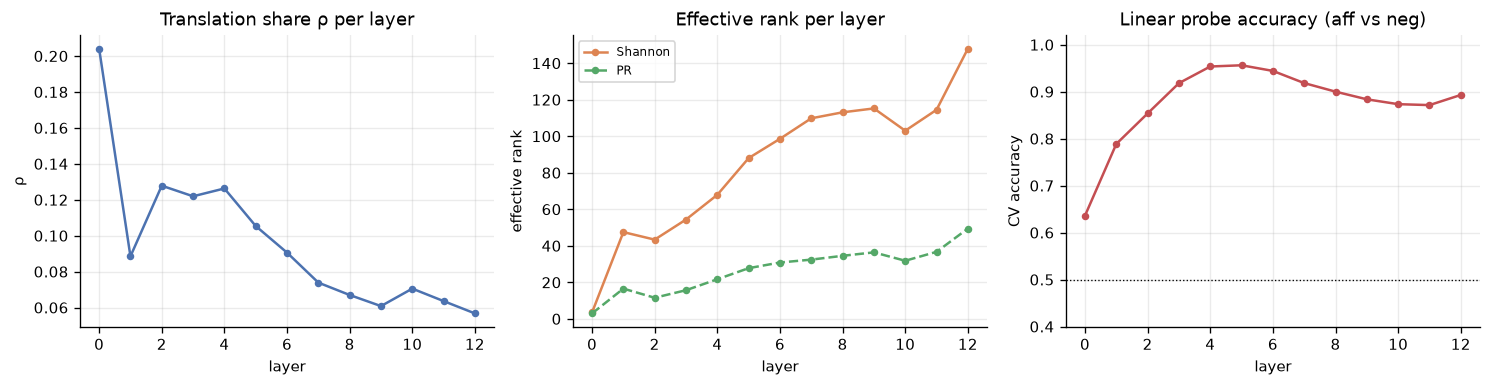

Best probe layer = 5 (acc 0.956, Shannon rank 88.07, ρ 0.105)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

LAYERS = list(range(0, N_TEXT_LAYERS + 1, CONFIG["layer_sweep_stride"]))
rows = []
for layer in LAYERS:
    a, b = get_embeddings(layer)
    dl = build_deltas(a, b)
    sp = spectrum_of(dl, center=False)
    mu = dl.mean(axis=0)
    share = float(mu @ mu / np.mean(np.sum(dl ** 2, axis=1)))

    X = np.vstack([l2n(a), l2n(b)])
    y = np.r_[np.zeros(len(a)), np.ones(len(b))]
    try:
        acc = float(cross_val_score(LogisticRegression(max_iter=2000, C=1.0), X, y,
                                    cv=min(5, int(min(np.bincount(y.astype(int))))), scoring="accuracy").mean())
    except Exception:
        acc = np.nan

    rows.append({"layer": layer, "translation_share": share,
                 "shannon_rank": shannon_effective_rank(sp.p),
                 "participation_ratio": participation_ratio(sp.eigenvalues),
                 "rank_tau90": rank_at_threshold(sp, 0.90), "probe_acc": acc})

LAYER_DF = pd.DataFrame(rows)
display(LAYER_DF.round(3))

fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.3))
ax[0].plot(LAYER_DF["layer"], LAYER_DF["translation_share"], "o-", ms=3.5, color="#4C72B0")
ax[0].set(title="Translation share ρ per layer", xlabel="layer", ylabel="ρ")
ax[1].plot(LAYER_DF["layer"], LAYER_DF["shannon_rank"], "o-", ms=3.5, label="Shannon", color="#DD8452")
ax[1].plot(LAYER_DF["layer"], LAYER_DF["participation_ratio"], "o--", ms=3.5, label="PR", color="#55A868")
ax[1].set(title="Effective rank per layer", xlabel="layer", ylabel="effective rank")
ax[1].legend(fontsize=7)
ax[2].plot(LAYER_DF["layer"], LAYER_DF["probe_acc"], "o-", ms=3.5, color="#C44E52")
ax[2].axhline(0.5, color="k", ls=":", lw=0.8)
ax[2].set(title="Linear probe accuracy (aff vs neg)", xlabel="layer", ylabel="CV accuracy", ylim=(0.4, 1.02))
fig.tight_layout()
plt.show()

best = LAYER_DF.loc[LAYER_DF["probe_acc"].idxmax()] if LAYER_DF["probe_acc"].notna().any() else None
if best is not None:
    print(f"Best probe layer = {int(best['layer'])} (acc {best['probe_acc']:.3f}, "
          f"Shannon rank {best['shannon_rank']:.2f}, ρ {best['translation_share']:.3f})")

## 12. Verdict

Maps the measured statistics onto H1–H4 and states what it implies for the correction operator and for the
cross-model transfer machinery. Thresholds live in `CONFIG` — they are deliberately explicit rather than
hidden inside the logic, because they encode a judgement call, not a fact.

In [ ]:
def verdict() -> dict:
    rho = translation_share
    r_sig = SIGNIFICANT_RANK
    intra, inter = MEAN_INTRA, MEAN_INTER
    has_types = (intra >= CONFIG["h2_min_intra_coherence"]) and (inter <= CONFIG["h2_max_inter_cosine"])

    # NOTE the ordering: H1 *is* a rank-1 outcome, so "nothing survives the null" must mean
    # strictly zero surviving components, otherwise a perfect translation gets misread as noise.
    if r_sig == 0:
        h, why = "H4?", "no component survives the null — check layers (§11) and the predictive test (§7) first"
    elif rho >= CONFIG["h1_translation_share"] and r_sig <= CONFIG["h1_max_rank"]:
        h, why = "H1", "the mean displacement dominates and almost no residual direction survives the null"
    elif r_sig <= CONFIG["h2_max_rank"] and has_types:
        h, why = "H2", "several significant components AND coherent, mutually distinct per-type directions"
    elif r_sig <= CONFIG["h2_max_rank"]:
        h, why = "H3", "several significant components but no per-type organisation — content-driven"
    else:
        h, why = "H4", "high significant rank: no low-dimensional linear structure"

    # A high translation share alongside a rank > 1 is a *mixed* regime: one shared displacement
    # plus genuine residual structure. That combination is both realistic and actionable.
    mixed = (h in {"H2", "H3"}) and (rho >= CONFIG["h1_translation_share"])

    plan = {
        "H1": ("single Householder reflection I − 2vvᵀ, no rule-based scope extraction",
               "classic orthogonal Procrustes on one vector"),
        "H2": ("soft mixture of per-type subspaces, weights = softmax of cosine to type centroids",
               "CCA + Procrustes on the subspace basis (reuse Agarwal's released pipeline)"),
        "H3": ("hybrid: global subspace projection + attention-weighted local content term",
               "CCA + Procrustes on the global part; local part recomputed natively per model"),
        "H4": ("try kernel PCA / a non-linear autoencoder bottleneck before abandoning the linear route",
               "autoencoder mapping (Oozeer et al.) rather than a linear map"),
    }[h.rstrip("?")]

    print("=" * 78)
    print(f"  VERDICT: {h}   —   {why}")
    print("=" * 78)
    print(f"  translation share rho          = {rho:.3f}")
    print(f"  significant rank (vs aff null) = {r_sig}")
    print(f"  significant rank (vs gaussian) = {sig_rank['gaussian']}")
    print(f"  Shannon effective rank         = {shannon_effective_rank(SPEC_UNCENTERED.p):.2f}")
    print(f"  participation ratio            = {participation_ratio(SPEC_UNCENTERED.eigenvalues):.2f}")
    print(f"  predictive rank (max excess R²)= {predictive_rank}")
    print(f"  intra-category coherence       = {intra:.3f}")
    print(f"  inter-category centroid cosine = {inter:.3f}")
    print("-" * 78)
    if mixed:
        print(f"  MIXED REGIME: rho = {rho:.2f} means a dominant shared translation coexists with")
        print(f"  {r_sig} significant residual directions. Model BOTH: subtract the mean displacement")
        print("  first, then apply the subspace operator to the residual.")
        print("-" * 78)
    print(f"  correction operator -> {plan[0]}")
    print(f"  transfer machinery  -> {plan[1]}")
    print("=" * 78)
    if DEMO:
        print('  (DEMO MODE — this verdict is meaningless; pick a real dataset via CONFIG["dataset"].)')

    return {"hypothesis": h, "translation_share": rho, "significant_rank": r_sig,
            "shannon_rank": shannon_effective_rank(SPEC_UNCENTERED.p),
            "participation_ratio": participation_ratio(SPEC_UNCENTERED.eigenvalues),
            "predictive_rank": predictive_rank, "intra_coherence": intra, "inter_cosine": inter}


RESULTS = verdict()

out_path = Path(CONFIG["cache_dir"]) / f"manip0_results_{DATASET}_{MODEL}_{cache_key(CONFIG['layer'])}.json"
out_path.write_text(json.dumps(
    {"config": {k: str(v) for k, v in CONFIG.items()}, "dataset": DATASET,
     "model": MSPEC["repo"], "pooling": POOLING, "n_pairs": int(N), "dim": int(D),
     "demo": DEMO, "results": {k: (float(v) if isinstance(v, (int, float, np.floating)) else v)
                               for k, v in RESULTS.items()}}, indent=2))
print(f"\nSaved -> {out_path}")

  VERDICT: H2   —   several significant components AND coherent, mutually distinct per-type directions
  translation share rho          = 0.060
  significant rank (vs aff null) = 1
  significant rank (vs gaussian) = 5
  Shannon effective rank         = 138.69
  participation ratio            = 45.56
  predictive rank (max excess R²)= 40
  intra-category coherence       = 0.485
  inter-category centroid cosine = 0.262
------------------------------------------------------------------------------
  correction operator -> soft mixture of per-type subspaces, weights = softmax of cosine to type centroids
  transfer machinery  -> CCA + Procrustes on the subspace basis (reuse Agarwal's released pipeline)

Saved -> ../data/cache/manip0_results_taxonomy_dff32504a3d7.json


## Next steps

1. **Run both datasets and compare.** Flip `CONFIG["dataset"]` between `"taxonomy"` and `"nevir"` and put
   the two verdicts side by side. A rank that agrees across a synthetic, template-generated set and a
   real-world IR corpus is a property of negation; a rank that only appears on `taxonomy` is a property of
   the generator's templates.
2. **Close the two gaps in the taxonomy generator**: a content field (`object`) crossed with `category`,
   so §8b can separate genuine type structure (H2) from content leaking into Δ (H3), and `mis-`/`anti-`
   rows so §9 can check the subspace is not keying on a surface prefix cue. Both sections are already
   wired — they self-skip only because those columns are absent.
3. **Re-run per layer** and keep the layer where the probe peaks and the effective rank bottoms out.
4. **Involution test** (separate notebook): build the operator implied by the verdict
   (translation / projection / reflection) and check which one satisfies $f(f(x)) \approx x$ on real
   double negations — the theoretical question none of the nine reviewed papers tests.
5. **Replicate on a second, independently trained encoder.** If the effective rank matches before any
   alignment, the dimensionality of negation is a property of the task rather than of one architecture.
6. **Then, and only then**, build the cross-model transfer with the machinery the verdict selected.